# 🚔 EDA & Feature Engineering: Crime Data Chicago
Halo! 👋 Saya Nasya, dan notebook ini merupakan hasil dari hands-on task saya 📊✨

Untuk menjaga relevansi data terhadap kondisi terkini, analisis pada notebook ini menggunakan data kriminalitas Chicago selama lima tahun terakhir (2021-2026). Rentang waktu tersebut menghasilkan lebih dari 1 juta observasi, sehingga sudah memadai untuk proses machine learning.

Selain itu, penggunaan data yang lebih baru juga mempertimbangkan fenomena *concept drift*, yaitu perubahan distribusi data dari waktu ke waktu yang dapat menyebabkan penurunan performa model apabila data historis yang digunakan terlalu lama. Hal ini didukung oleh penelitian Uchida & Yoshida (2023) yang menunjukkan bahwa perubahan distribusi data dapat memengaruhi akurasi model prediksi. Pemilihan rentang lima tahun juga sejalan dengan penelitian Jean & Roy (2026) yang berhasil mengembangkan model prediksi kriminalitas Chicago menggunakan data periode 2017–2021.

**Daftar isi:**
1. 🧹 Data Cleaning
2. 📊 Exploratory Data Analysis (10 visualisasi + insight)
3. ⚙️ Feature Engineering (temporal cyclical & spatial grid)

---

**Referensi:**
- Uchida T and Yoshida K (2023) A brute force tuning of training length for concept drift. Front. Phys. 10:1016564. https://doi.org/10.3389/fphy.2022.1016564   

- Jean, R., & Roy, S. (2026). Multi-Scale Geo-Temporal Crime Embedding (MSG-TCE): A Hierarchical Spatiotemporal Framework for Crime Prediction with Hyperbolic Spatial Pooling and Periodic Transformers. ISPRS International Journal of Geo-Information, 15(7), 299. https://doi.org/10.3390/ijgi15070299


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# palet warna yang digunakan
CAT15 = ["#2E86AB","#A23B72","#F18F01","#C73E1D","#3B7A57","#6A4C93","#118AB2",
         "#EF476F","#06D6A0","#8338EC","#FB5607","#5B5F97","#BC6C25","#277DA1","#D62839"]
SEQ = "mako"
BG  = "#FAFAF7"
DOW_LABEL = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']

sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": BG, "figure.facecolor": BG,
    "axes.edgecolor": "#444444", "grid.color": "#C9C6BB", "grid.linewidth": 0.8,
})
pd.set_option('display.max_columns', 30)

## 🧹 1. Data Cleaning

Tahap data cleaning pada hands-on ini sebenarnya sudah disediakan pada modul sehingga fokus utama berada pada proses Exploratory Data Analysis (EDA) dan Feature Engineering. Meskipun demikian, saya tetap melakukan seluruh proses cleaning secara bertahap agar memahami tujuan dari setiap langkah yang dilakukan sebelum data digunakan pada tahap analisis.

Beberapa proses pembersihan data yang dilakukan meliputi:

1. **Mengubah kolom Date menjadi tipe datetime** sehingga informasi waktu seperti jam, hari, dan bulan dapat diekstraksi untuk analisis selanjutnya.
2. **Menghapus data yang tidak memiliki informasi tanggal maupun koordinat** (Latitude dan Longitude) karena data tersebut tidak dapat digunakan dalam analisis temporal maupun pemetaan spasial.
3. **Memfilter koordinat yang berada di luar bounding box Kota Chicago** untuk menghilangkan data dengan koordinat yang tidak valid sehingga hasil analisis spasial tidak terpengaruh oleh titik lokasi yang keliru.
4. **Membentuk fitur waktu dasar**, yaitu hour, dow (day of week), dan month, yang nantinya akan digunakan pada tahap EDA serta Feature Engineering.


In [2]:
df = pd.read_csv('DATASET.csv', sep=';')
print("Shape awal:", df.shape)

# 1. Ambil koordinat bersih dari kolom Location
loc = df['Location'].str.extract(r'\(([-0-9\.]+) ([-0-9\.]+)\)')
df['Longitude'] = pd.to_numeric(loc[0], errors='coerce')
df['Latitude']  = pd.to_numeric(loc[1], errors='coerce')

# 2. Parse Date -> datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %H:%M', errors='coerce')

# 3. Buang baris tanpa koordinat / tanggal valid
before = len(df)
df = df.dropna(subset=['Latitude','Longitude','Date']).copy()
print(f"Dibuang krn koordinat/tanggal kosong : {before-len(df):,} baris")

# 4. Filter bounding box kasar kota Chicago (buang koordinat rusak)
before = len(df)
df = df[df['Latitude'].between(41.6, 42.05) & df['Longitude'].between(-87.95, -87.5)].copy()
print(f"Dibuang krn di luar bounding box     : {before-len(df):,} baris")

# 5. Turunkan fitur waktu dasar
df['hour']  = df['Date'].dt.hour
df['dow']   = df['Date'].dt.dayofweek   # 0 = Senin ... 6 = Minggu
df['month'] = df['Date'].dt.month

print("Shape final:", df.shape)
df[['Date','Primary Type','Latitude','Longitude','hour','dow','month']].head()

Shape awal: (1002744, 22)
Dibuang krn koordinat/tanggal kosong : 8,091 baris
Dibuang krn di luar bounding box     : 2 baris
Shape final: (994651, 25)


,Date,Primary Type,Latitude,Longitude,hour,dow,month
0,2022-07-06 12:00:00,THEFT,41.894430,-87.624241,12,2,7
1,2022-07-06 12:00:00,DECEPTIVE PRACTICE,41.960047,-87.646762,12,2,7
2,2022-07-06 12:00:00,OTHER OFFENSE,41.901303,-87.714183,12,2,7
3,2022-07-06 12:00:00,DECEPTIVE PRACTICE,41.916004,-87.726526,12,2,7
5,2022-07-06 12:00:00,DECEPTIVE PRACTICE,42.014242,-87.684968,12,2,7


✅ **Hasil cleaning:** dari ±1 juta baris data mentah, didapatkan **994.651 baris (~99,2%)** yang layak dianalisis

---
## 📊 2. Exploratory Data Analysis
Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data kriminalitas Chicago sebelum memasuki proses Feature Engineering. Selain mengidentifikasi pola distribusi data, EDA pada notebook ini juga bertujuan menemukan insight yang dapat menjadi dasar dalam menentukan fitur temporal maupun spasial yang relevan untuk pemodelan risiko kejahatan.

Berdasarkan arahan pada hands-on, eksplorasi tidak hanya dilakukan pada masing-masing variabel secara terpisah, tetapi juga pada hubungan antarvariabel agar pola yang sebelumnya tidak terlihat dapat teridentifikasi.

**📌Oleh karena itu, analisis pada notebook ini mencakup sepuluh visualisasi berikut.**
1. Top 15 Jenis Kejahatan
2. Distribusi Kejahatan Berdasarkan Jam
3. Distribusi Kejahatan Berdasarkan Hari dalam Seminggu
4. Distribusi Kejahatan Berdasarkan Bulan
5. Heatmap Hari × Jam Kejadian
6. Perbandingan Weekday vs Weekend
7. Heatmap Jenis Kejahatan × Jam
8. Heatmap Jenis Kejahatan × Location Description
9. Peta Hotspot Kejahatan
10. Peta Hotspot Berdasarkan Jenis Kejahatan

### 1️⃣ Top 15 Jenis Kejahatan

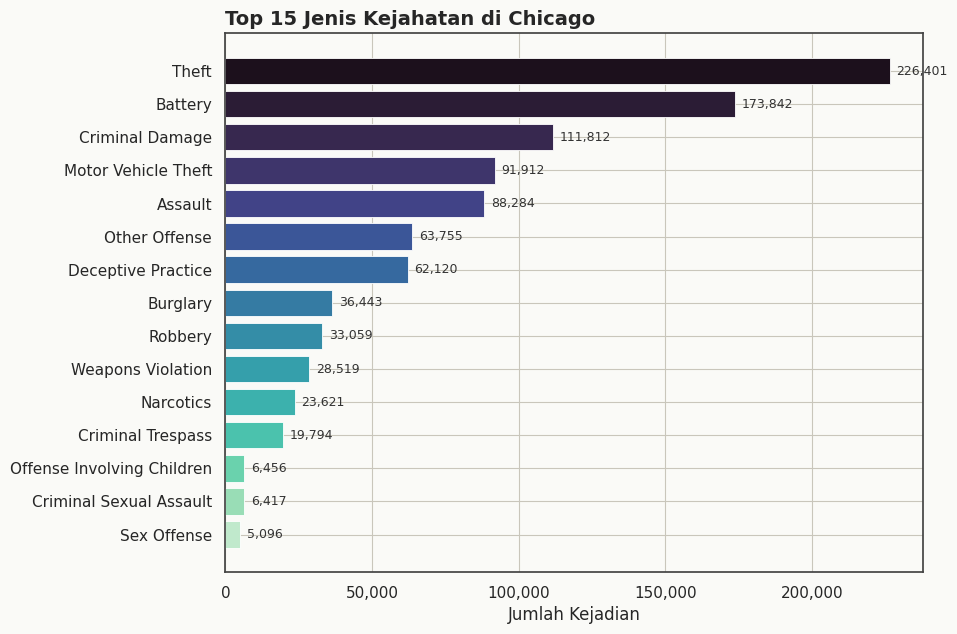

In [3]:
top15 = df['Primary Type'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(9,7))
colors = sns.color_palette(SEQ, n_colors=len(top15))[::-1]
bars = ax.barh(top15.index.str.title(), top15.values, color=colors, edgecolor='white', linewidth=0.6)
for b, v in zip(bars, top15.values):
    ax.text(v+max(top15.values)*0.01, b.get_y()+b.get_height()/2, f'{v:,}', va='center', fontsize=9, color='#333')
ax.set_xlabel('Jumlah Kejadian')
ax.set_title('Top 15 Jenis Kejahatan di Chicago', fontsize=14, weight='bold', loc='left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.show()


**Insight 💡:** Berdasarkan distribusi jumlah kejadian,`THEFT` (pencurian) merupakan jenis kejahatan yang paling sering terjadi selama periode pengamatan, diikuti oleh `BATTERY` (penganiayaan ringan) dan `CRIMINAL DAMAGE` Dominasi ketiga kategori ini menunjukkan bahwa sebagian besar kasus kriminalitas di Chicago berasal dari jenis kejahatan tersebut. Oleh karena itu, ketiga kategori ini menjadi fokus yang penting untuk dianalisis lebih lanjut, baik dalam mengidentifikasi pola temporal maupun pola spasial.


### 2️⃣ Distribusi Kejahatan berdasarkan Jam

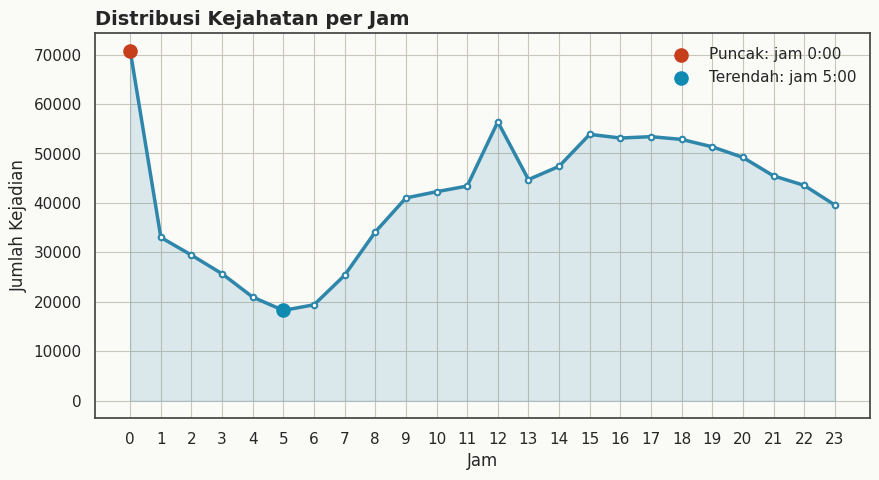

In [4]:
hourly = df.groupby('hour').size()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(hourly.index, hourly.values, color=CAT15[0], linewidth=2.5, marker='o',
        markersize=4, markerfacecolor='white', markeredgewidth=1.5)
ax.fill_between(hourly.index, hourly.values, color=CAT15[0], alpha=0.15)

peak_h, low_h = hourly.idxmax(), hourly.idxmin()
ax.scatter([peak_h],[hourly[peak_h]], color=CAT15[3], s=90, zorder=5, label=f'Puncak: jam {peak_h}:00')
ax.scatter([low_h],[hourly[low_h]], color=CAT15[6], s=90, zorder=5, label=f'Terendah: jam {low_h}:00')

ax.set_xticks(range(0,24))
ax.set_xlabel('Jam'); ax.set_ylabel('Jumlah Kejadian')
ax.set_title('Distribusi Kejahatan per Jam', fontsize=14, weight='bold', loc='left')
ax.legend(frameon=False)
plt.show()

**Insight 💡:** Distribusi kejadian menunjukkan bahwa jumlah kasus tertinggi tercatat pada pukul 00.00. Pola ini diduga berkaitan dengan fenomena *midnight bucket*, yaitu ketika waktu pasti suatu kejadian tidak diketahui sehingga secara administratif dicatat pada pukul 00.00.

Interpretasi ini sejalan dengan dokumentasi resmi Chicago Crimes Dataset yang menyatakan bahwa waktu kejadian yang tercatat merupakan "best estimate", sehingga tidak selalu merepresentasikan waktu kejadian yang sebenarnya.

Di luar pola tersebut, jumlah kejadian kembali meningkat pada rentang 12.00–17.00, sedangkan frekuensi terendah terjadi pada sekitar 04.00–06.00. Temuan ini menunjukkan bahwa risiko kejahatan tidak hanya terkonsentrasi pada malam hari, tetapi juga relatif tinggi pada siang hingga sore hari. Oleh karena itu, jam kejadian berpotensi menjadi fitur temporal yang penting dalam pemodelan risiko kejahatan.

---
**Referensi**: Chicago Police Department. (2026). Crimes – 2001 to Present. City of Chicago Data Portal. https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2

### 3️⃣ Distribusi Kejahatan berdasarkan Hari dalam Seminggu

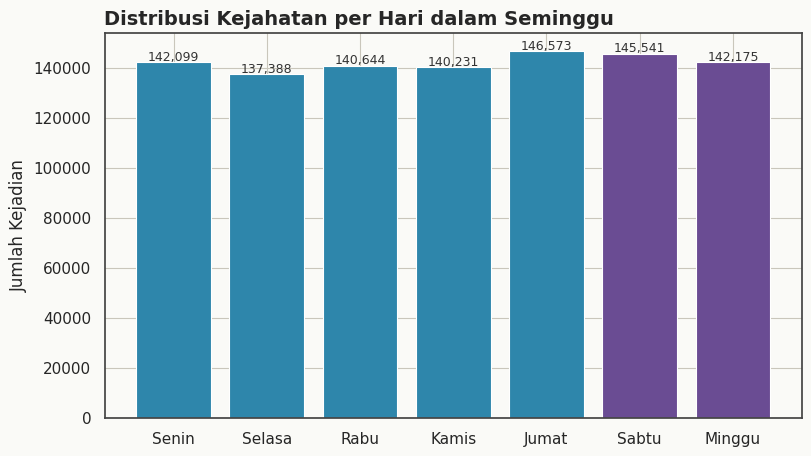

In [5]:
dow_ct = df.groupby('dow').size()
dow_ct.index = [DOW_LABEL[i] for i in dow_ct.index]
dow_ct = dow_ct.reindex(DOW_LABEL)

fig, ax = plt.subplots(figsize=(9,5))
colors_dow = [CAT15[5] if d in ['Sabtu','Minggu'] else CAT15[0] for d in DOW_LABEL]
bars = ax.bar(dow_ct.index, dow_ct.values, color=colors_dow, edgecolor='white', linewidth=0.8)
for b,v in zip(bars, dow_ct.values):
    ax.text(b.get_x()+b.get_width()/2, v+800, f'{v:,}', ha='center', fontsize=9, color='#333')
ax.set_ylabel('Jumlah Kejadian')
ax.set_title('Distribusi Kejahatan per Hari dalam Seminggu', fontsize=14, weight='bold', loc='left')
plt.show()

**Insight 💡:** Distribusi jumlah kejadian berdasarkan hari menunjukkan bahwa perbedaannya relatif tidak terlalu besar, dengan rentang sekitar 137 ribu–146 ribu kejadian. Meskipun demikian, Jumat mencatat jumlah kejadian tertinggi, sedangkan Selasa merupakan hari dengan jumlah kejadian terendah. Temuan ini menunjukkan bahwa hari dalam seminggu tetap memiliki pengaruh terhadap distribusi kriminalitas, meskipun variasinya tidak setajam pola berdasarkan jam kejadian. Oleh karena itu, fitur day of week (dow) tetap layak dipertimbangkan pada tahap Feature Engineering, meskipun kemungkinan kontribusinya tidak sebesar fitur hour.


### 4️⃣ Heatmap Hari × Jam

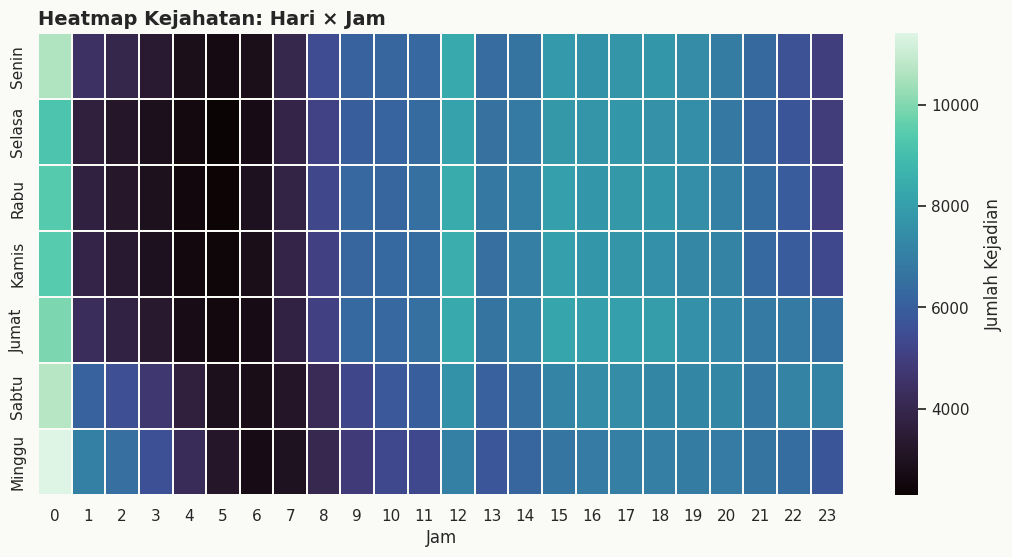

In [6]:
pivot_dh = df.groupby(['dow','hour']).size().unstack(fill_value=0)
pivot_dh.index = [DOW_LABEL[i] for i in pivot_dh.index]

fig, ax = plt.subplots(figsize=(13,6))
sns.heatmap(pivot_dh, cmap=SEQ, ax=ax, cbar_kws={'label':'Jumlah Kejadian'}, linewidths=0.3, linecolor=BG)
ax.set_xlabel('Jam'); ax.set_ylabel('')
ax.set_title('Heatmap Kejahatan: Hari × Jam', fontsize=14, weight='bold', loc='left')
plt.show()

**Insight 💡:** Heatmap menunjukkan bahwa pola kejadian menjadi lebih jelas ketika hari dan jam dianalisis secara bersamaan. Konsentrasi kejadian tertinggi terlihat pada rentang siang hingga sore hari di hampir seluruh hari dalam seminggu, dengan peningkatan yang lebih menonjol pada Jumat dan Sabtu malam. Temuan ini mengindikasikan bahwa risiko kejahatan tidak hanya dipengaruhi oleh jam atau hari secara terpisah, tetapi juga oleh interaksi keduanya. Oleh karena itu, kombinasi fitur temporal, seperti day of week × hour, berpotensi memberikan informasi yang lebih representatif dibandingkan menggunakan masing-masing fitur secara terpisah.

### 5️⃣ Perbandingan Weekday vs Weekend

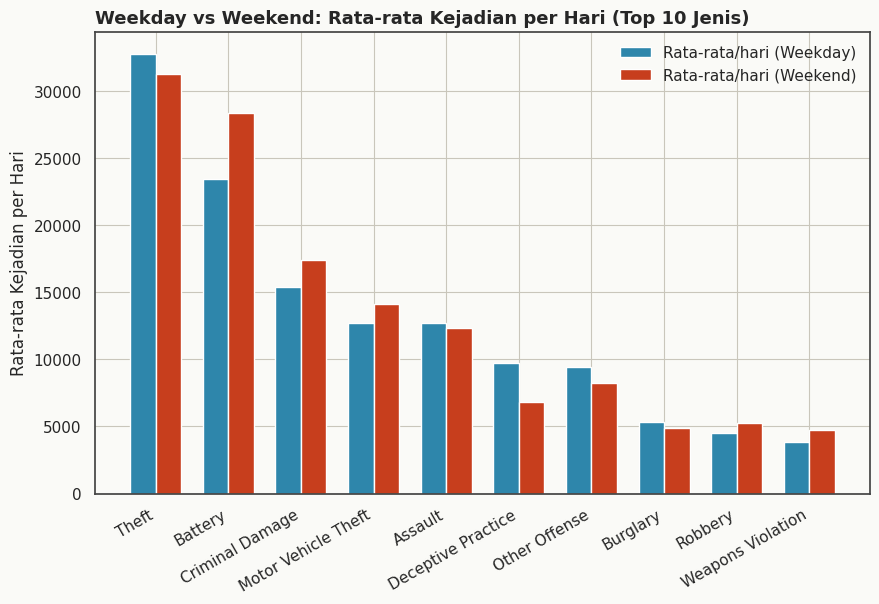

In [7]:
df['is_weekend'] = df['dow'] >= 5
top10 = df['Primary Type'].value_counts().head(10).index
tmp = df[df['Primary Type'].isin(top10)].copy()

grp = tmp.groupby(['Primary Type','is_weekend']).size().unstack(fill_value=0)
grp.columns = ['Weekday','Weekend']
# dibagi jumlah harinya (5 weekday, 2 weekend) biar adil dibandingkan
grp['Weekday_rate'] = grp['Weekday']/5
grp['Weekend_rate'] = grp['Weekend']/2
grp = grp.loc[grp['Weekday_rate'].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(grp)); w = 0.35
ax.bar(x-w/2, grp['Weekday_rate'], width=w, label='Rata-rata/hari (Weekday)', color=CAT15[0])
ax.bar(x+w/2, grp['Weekend_rate'], width=w, label='Rata-rata/hari (Weekend)', color=CAT15[3])
ax.set_xticks(x); ax.set_xticklabels([c.title() for c in grp.index], rotation=30, ha='right')
ax.set_ylabel('Rata-rata Kejadian per Hari')
ax.set_title('Weekday vs Weekend: Rata-rata Kejadian per Hari (Top 10 Jenis)', fontsize=13, weight='bold', loc='left')
ax.legend(frameon=False)
plt.show()

**Insight 💡:** Perbandingan ini telah dinormalisasi berdasarkan jumlah hari (5 hari kerja dan 2 hari akhir pekan) sehingga mencerminkan rata-rata kejadian per hari, bukan total kejadian.

Pada 10 jenis kejahatan dengan frekuensi tertinggi, terlihat bahwa`BATTERY`dan `CRIMINAL DAMAGE` memiliki rata-rata kejadian per hari yang lebih tinggi pada akhir pekan, sedangkan `DECEPTIVE PRACTICE` (penipuan) lebih banyak terjadi pada hari kerja.

Perbedaan pola ini menunjukkan bahwa komposisi jenis kejahatan dapat berubah antara weekday dan weekend. Oleh karena itu, fitur `is_weekend`  berpotensi memberikan informasi tambahan yang relevan dalam proses pemodelan risiko kejahatan.


### 6️⃣ Heatmap Jenis Kejahatan × Jam

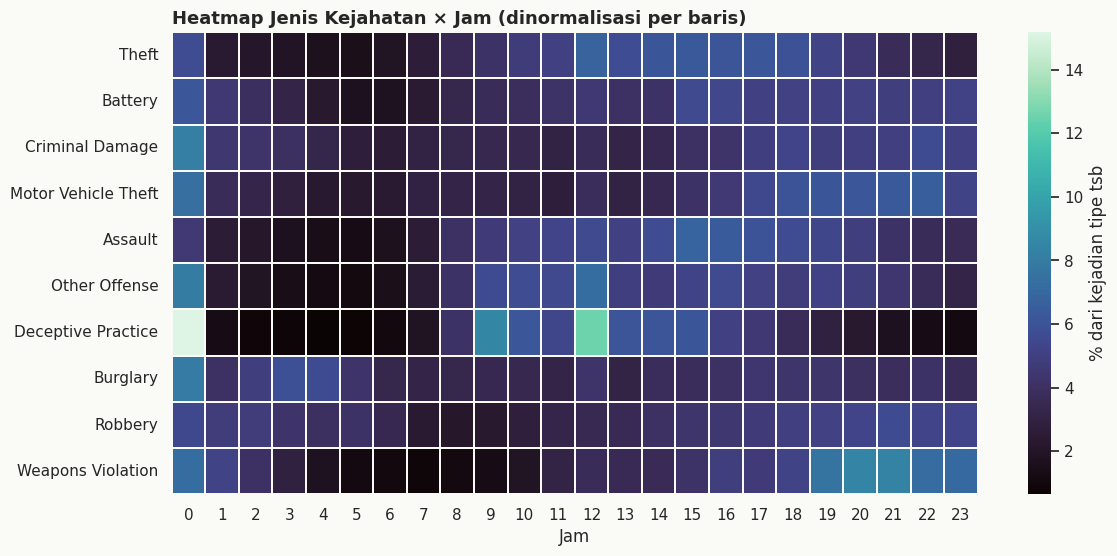

In [8]:
top10 = df['Primary Type'].value_counts().head(10).index
tmp = df[df['Primary Type'].isin(top10)]
pivot_th = tmp.groupby(['Primary Type','hour']).size().unstack(fill_value=0).loc[top10]
pivot_th_pct = pivot_th.div(pivot_th.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13,6))
sns.heatmap(pivot_th_pct, cmap=SEQ, ax=ax, cbar_kws={'label':'% dari kejadian tipe tsb'}, linewidths=0.3, linecolor=BG)
ax.set_yticklabels([t.title() for t in pivot_th_pct.index], rotation=0)
ax.set_xlabel('Jam'); ax.set_ylabel('')
ax.set_title('Heatmap Jenis Kejahatan × Jam (dinormalisasi per baris)', fontsize=13, weight='bold', loc='left')
plt.show()

**Insight 💡:** Heatmap ini menggunakan normalisasi per baris (persentase) agar pola waktu pada setiap jenis kejahatan dapat dibandingkan secara lebih adil. Jika menggunakan jumlah kejadian mentah, jenis kejahatan dengan frekuensi tinggi, seperti `THEFT`, akan mendominasi visualisasi sehingga pola pada jenis kejahatan lain menjadi sulit diamati.

Setelah dinormalisasi, terlihat bahwa `NARCOTICS` (narkoba) lebih banyak terjadi pada sore hingga malam hari, `BATTERY` & `ASSAULT` menunjukkan peningkatan pada malam hari, sedangkan `DECEPTIVE PRACTICE` cenderung lebih merata pada jam kerja. Temuan ini menunjukkan bahwa setiap jenis kejahatan memiliki pola temporal yang berbeda, sehingga jenis kejahatan dan waktu kejadian berpotensi memberikan informasi yang saling melengkapi dalam proses Feature Engineering maupun analisis risiko kejahatan.

### 7️⃣ Heatmap Jenis Kejahatan × Lokasi Kejadian

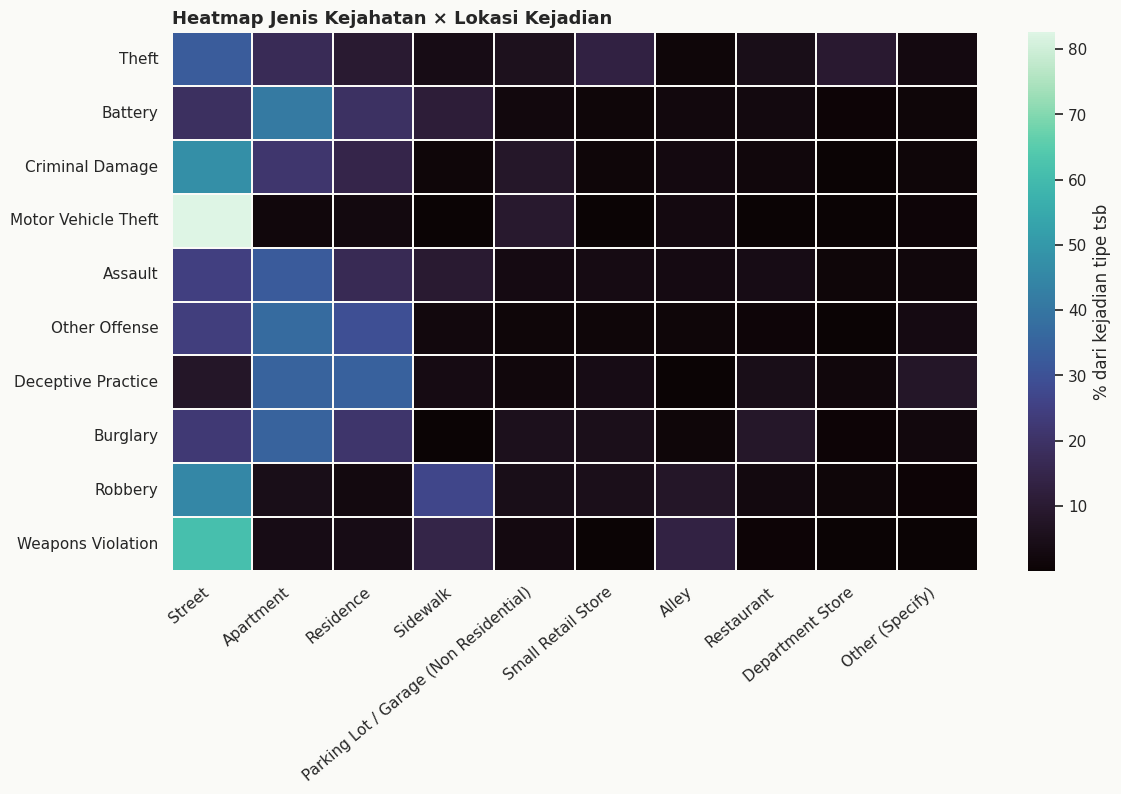

In [9]:
top10loc = df['Location Description'].value_counts().head(10).index
tmp2 = df[df['Primary Type'].isin(top10) & df['Location Description'].isin(top10loc)]
pivot_tl = tmp2.groupby(['Primary Type','Location Description']).size().unstack(fill_value=0).loc[top10, top10loc]
pivot_tl_pct = pivot_tl.div(pivot_tl.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13,7))
sns.heatmap(pivot_tl_pct, cmap=SEQ, ax=ax, cbar_kws={'label':'% dari kejadian tipe tsb'}, linewidths=0.3, linecolor=BG)
ax.set_yticklabels([t.title() for t in pivot_tl_pct.index], rotation=0)
ax.set_xticklabels([t.title() for t in pivot_tl_pct.columns], rotation=40, ha='right')
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_title('Heatmap Jenis Kejahatan × Lokasi Kejadian', fontsize=13, weight='bold', loc='left')
plt.show()

**Insight 💡:** Heatmap menunjukkan bahwa setiap jenis kejahatan memiliki kecenderungan terjadi pada lokasi yang berbeda. Sebagai contoh, `MOTOR VEHICLE THEFT` lebih banyak tercatat pada area jalan dan parkir, `NARCOTICS` relatif sering terjadi di jalan maupun gang, sedangkan`OFFENSE INVOLVING CHILDREN` lebih banyak ditemukan pada area permukiman, seperti rumah atau apartemen. Temuan ini mengindikasikan bahwa karakteristik lokasi berperan dalam membedakan pola setiap jenis kejahatan.

### 8️⃣ Peta Hotspot Kejahatan (Keseluruhan)

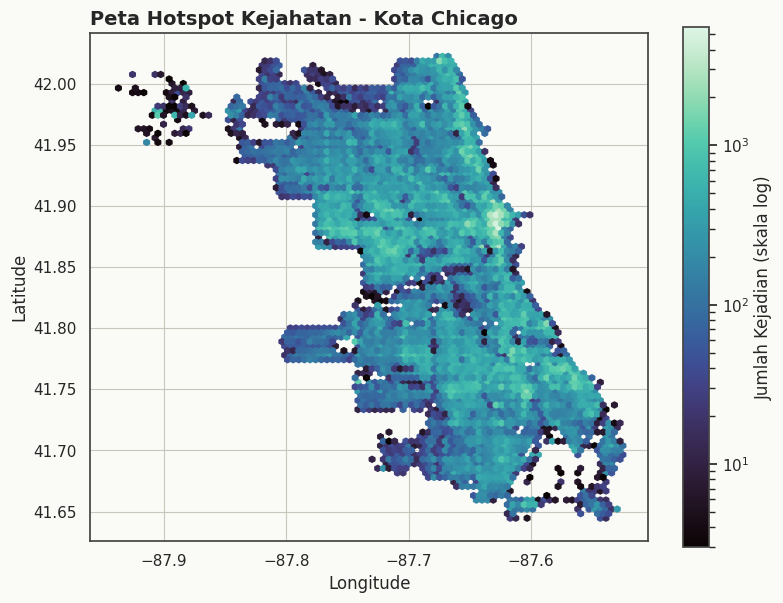

In [10]:
fig, ax = plt.subplots(figsize=(9,9))
hb = ax.hexbin(df['Longitude'], df['Latitude'], gridsize=90, cmap=SEQ, mincnt=3, bins='log')
cb = fig.colorbar(hb, ax=ax, shrink=0.75)
cb.set_label('Jumlah Kejadian (skala log)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Peta Hotspot Kejahatan - Kota Chicago', fontsize=14, weight='bold', loc='left')
ax.set_aspect('equal')
plt.show()

**Insight 💡:** Visualisasi menunjukkan bahwa kejadian kriminal tidak terdistribusi secara merata di seluruh wilayah Chicago. Terdapat beberapa area dengan konsentrasi kejadian yang jauh lebih tinggi dibandingkan wilayah lainnya, terutama pada bagian tengah kota serta beberapa area di selatan dan barat.

Untuk mempermudah interpretasi, visualisasi menggunakan skala logaritmik karena jumlah kejadian antarwilayah memiliki rentang yang sangat lebar. Dengan pendekatan ini, area dengan frekuensi kejadian yang lebih rendah tetap dapat diamati tanpa tertutupi oleh area dengan jumlah kejadian yang sangat tinggi. Temuan ini menunjukkan bahwa lokasi merupakan faktor penting dalam distribusi kriminalitas, sehingga representasi spasial, seperti grid aggregation, berpotensi menjadi fitur yang relevan pada tahap Feature Engineering.

### 9️⃣ Peta Hotspot berdasarkan Jenis Kejahatan

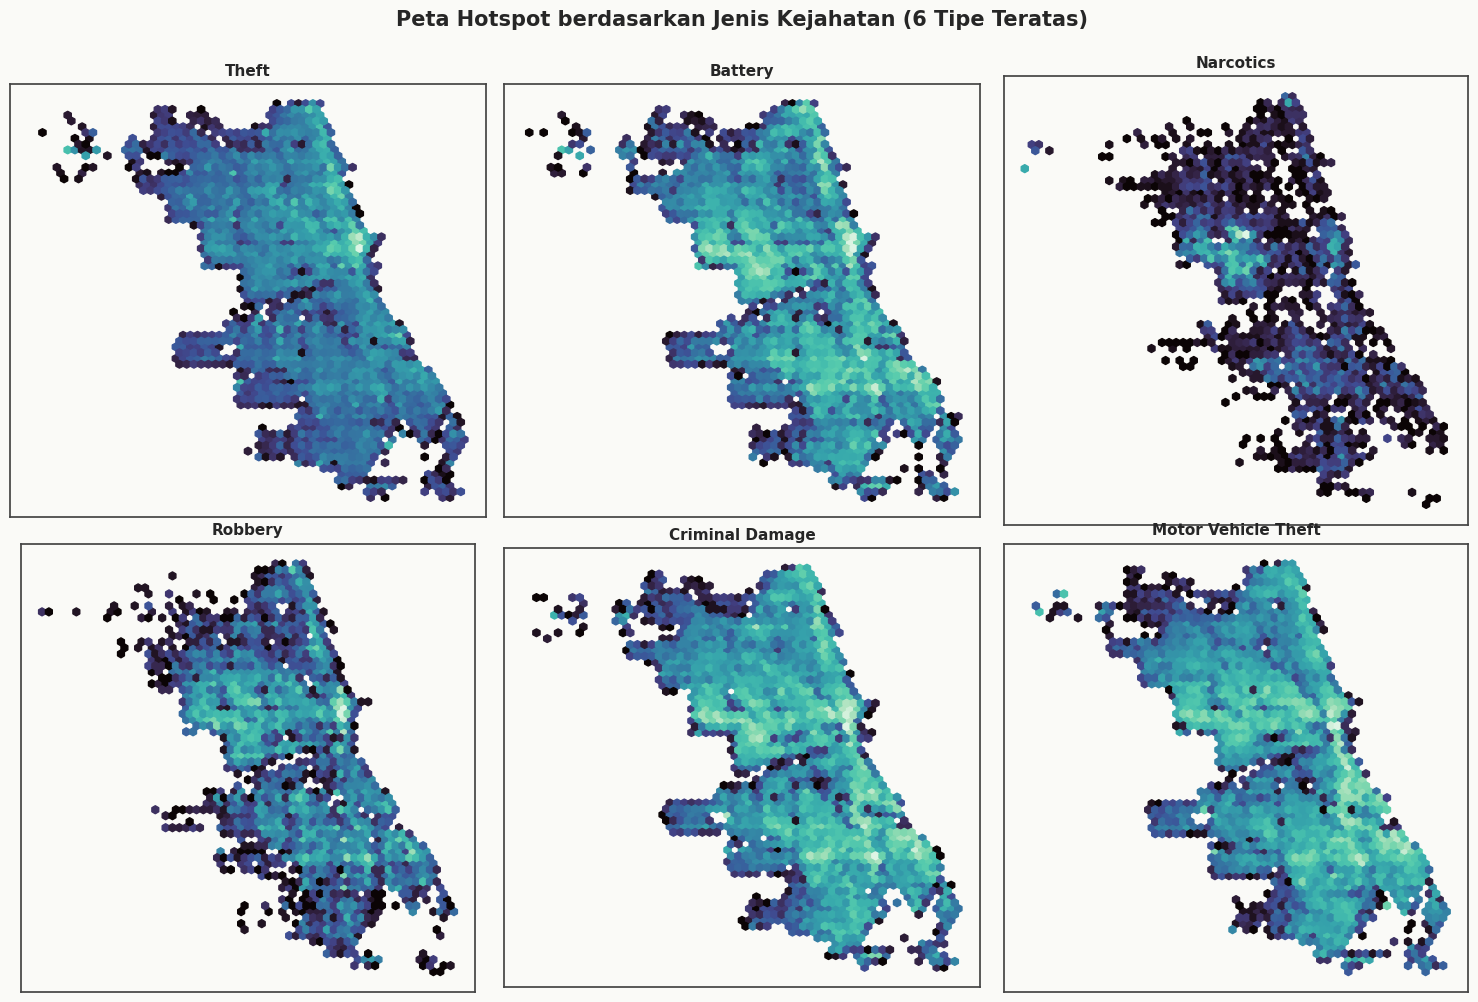

In [11]:
sel_types = ['THEFT','BATTERY','NARCOTICS','ROBBERY','CRIMINAL DAMAGE','MOTOR VEHICLE THEFT']
fig, axes = plt.subplots(2, 3, figsize=(15,10))
for ax, t in zip(axes.flat, sel_types):
    sub = df[df['Primary Type']==t]
    ax.hexbin(sub['Longitude'], sub['Latitude'], gridsize=60, cmap=SEQ, mincnt=2, bins='log')
    ax.set_title(t.title(), fontsize=11, weight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')
fig.suptitle('Peta Hotspot berdasarkan Jenis Kejahatan (6 Tipe Teratas)', fontsize=15, weight='bold', y=1.00)
fig.tight_layout()
plt.show()

**Insight 💡:** Peta hotspot menunjukkan bahwa pola persebaran setiap jenis kejahatan tidak selalu mengikuti pola hotspot kriminalitas secara keseluruhan. Sebagai contoh, `NARCOTICS` terlihat lebih terkonsentrasi pada beberapa area tertentu, sedangkan `THEFT`  memiliki persebaran yang lebih luas mengikuti wilayah dengan aktivitas yang tinggi. Temuan ini mengindikasikan bahwa karakteristik spasial dapat berbeda untuk setiap jenis kejahatan.

### 🔟 Arrest Rate berdasarkan Jenis Kejahatan

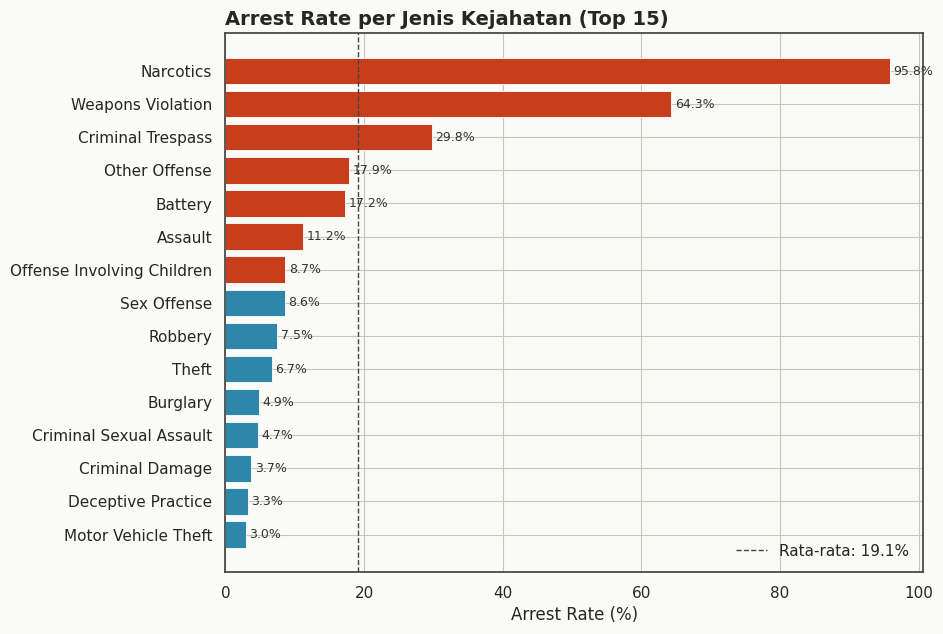

In [12]:
top15types = df['Primary Type'].value_counts().head(15).index
arate = (df[df['Primary Type'].isin(top15types)]
         .groupby('Primary Type')['Arrest'].mean() * 100).loc[top15types].sort_values()

fig, ax = plt.subplots(figsize=(9,7))
colors = [CAT15[3] if v > arate.median() else CAT15[0] for v in arate.values]
bars = ax.barh(arate.index.str.title(), arate.values, color=colors, edgecolor='white', linewidth=0.6)
for b,v in zip(bars, arate.values):
    ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9, color='#333')
ax.axvline(arate.mean(), color='#444', linestyle='--', linewidth=1, label=f'Rata-rata: {arate.mean():.1f}%')
ax.set_xlabel('Arrest Rate (%)')
ax.set_title('Arrest Rate per Jenis Kejahatan (Top 15)', fontsize=14, weight='bold', loc='left')
ax.legend(frameon=False)
plt.show()

**Insight 💡:** Terdapat perbedaan arrest rate yang sangat besar antar jenis kejahatan. `NARCOTICS` memiliki arrest rate tertinggi, yaitu sekitar 96%, sedangkan `MOTOR VEHICLE THEFT` memiliki arrest rate terendah, yaitu sekitar 3%. Temuan ini menunjukkan bahwa peluang suatu kasus berujung pada penangkapan tidak hanya dipengaruhi oleh banyaknya kejadian, tetapi juga bervariasi menurut karakteristik masing-masing jenis kejahatan.

---
## ⚙️ 3. Feature Engineering
Tahap Feature Engineering dilakukan untuk mengubah data mentah menjadi representasi yang lebih sesuai bagi model machine learning. Berdasarkan hasil Exploratory Data Analysis (EDA), terlihat bahwa pola kriminalitas dipengaruhi oleh aspek temporal maupun spasial.

Pada notebook ini, proses Feature Engineering difokuskan pada dua jenis fitur utama, yaitu:
- Fitur temporal, karena variabel waktu memiliki sifat siklikal. Sebagai contoh, pukul 23.00 sebenarnya berdekatan dengan 00.00, begitu pula Desember yang berdekatan dengan Januari.
- Fitur spasial, karena koordinat Latitude dan Longitude bersifat kontinu dengan tingkat presisi yang tinggi.

Berdasarkan karakteristik tersebut, Feature Engineering pada notebook ini dibagi menjadi dua bagian, yaitu **Temporal Feature Engineering** dan **Spatial Feature Engineering.**👇


### ⏱️ 3.1 Temporal: Representasi Siklik

**Solusi yang digunakan:** ubah jam (atau hari, atau bulan) menjadi dua fitur `sin` dan `cos` pada lingkaran, formulanya:

$$x_{\sin} = \sin\left(\frac{2\pi \cdot t}{T}\right) \qquad x_{\cos} = \cos\left(\frac{2\pi \cdot t}{T}\right)$$

dengan $T$ = panjang siklusnya (24 buat jam, 7 buat hari, 12 buat bulan).

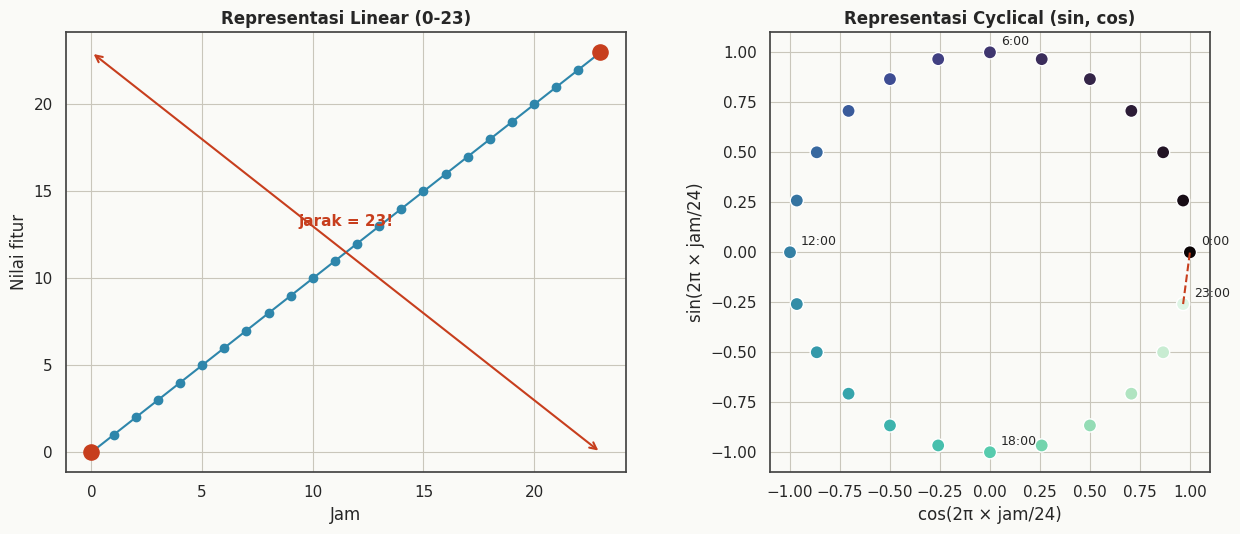

In [13]:
hours = np.arange(24)
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

# kiri: representasi linear -> jam 23 & jam 0 keliatan jauh
ax = axes[0]
ax.plot(hours, hours, 'o-', color=CAT15[0])
ax.scatter([23,0],[23,0], color=CAT15[3], s=120, zorder=5)
ax.annotate('', xy=(23,0), xytext=(0,23), arrowprops=dict(arrowstyle='<->', color=CAT15[3], lw=1.5))
ax.text(11.5,13,'jarak = 23!', color=CAT15[3], fontsize=11, weight='bold', ha='center')
ax.set_title('Representasi Linear (0-23)', fontsize=12, weight='bold')
ax.set_xlabel('Jam'); ax.set_ylabel('Nilai fitur')

# kanan: representasi cyclical -> jam 23 & jam 0 deketan
theta = 2*np.pi*hours/24
ax2 = axes[1]
ax2.scatter(np.cos(theta), np.sin(theta), c=hours, cmap=SEQ, s=90, edgecolor='white')
for h in [0,6,12,18,23]:
    t = 2*np.pi*h/24
    ax2.annotate(f'{h}:00', (np.cos(t), np.sin(t)), textcoords="offset points", xytext=(8,5), fontsize=9)
ax2.plot([np.cos(2*np.pi*23/24), np.cos(0)], [np.sin(2*np.pi*23/24), np.sin(0)], '--', color=CAT15[3], lw=1.5)
ax2.set_title('Representasi Cyclical (sin, cos)', fontsize=12, weight='bold')
ax2.set_xlabel('cos(2π × jam/24)'); ax2.set_ylabel('sin(2π × jam/24)')
ax2.set_aspect('equal')
fig.tight_layout()
plt.show()

In [14]:
def lin_dist(a, b):
    return abs(a - b)

def cyc_dist(a, b, period=24):
    ta, tb = 2*np.pi*a/period, 2*np.pi*b/period
    return np.sqrt((np.cos(ta)-np.cos(tb))**2 + (np.sin(ta)-np.sin(tb))**2)

for a, b in [(23,0), (1,23), (12,0), (6,18)]:
    print(f"jam {a:>2} vs {b:>2}  ->  linear = {lin_dist(a,b):5.1f}   |   cyclical = {cyc_dist(a,b):.3f}")

jam 23 vs  0  ->  linear =  23.0   |   cyclical = 0.261
jam  1 vs 23  ->  linear =  22.0   |   cyclical = 0.518
jam 12 vs  0  ->  linear =  12.0   |   cyclical = 2.000
jam  6 vs 18  ->  linear =  12.0   |   cyclical = 2.000


**Insight 💡:** Perbandingan antara representasi linear dan cyclical encoding menunjukkan perbedaan yang cukup signifikan. Sebagai contoh, pukul 23.00 dan 00.00 memiliki selisih 23 jika direpresentasikan secara linear, padahal kedua waktu tersebut sebenarnya berdekatan dalam satu siklus harian.

Dengan cyclical encoding, jarak keduanya menjadi sekitar 0,261, sehingga hubungan antarwaktu dapat direpresentasikan dengan lebih sesuai. Sebaliknya, pukul 12.00 dan 00.00 tetap memiliki jarak yang besar, baik pada representasi linear maupun cyclical, karena memang berada pada posisi yang berlawanan dalam satu siklus. Hal ini menunjukkan bahwa cyclical encoding mampu merepresentasikan karakteristik siklikal pada data temporal dengan lebih baik dibandingkan representasi numerik biasa.

### 📅 Question: Apakah `month` perlu?

Sebelum lanjut, dilakukan pengecekan apakah variasi bulanan ini emang nyata atau cuma noise.

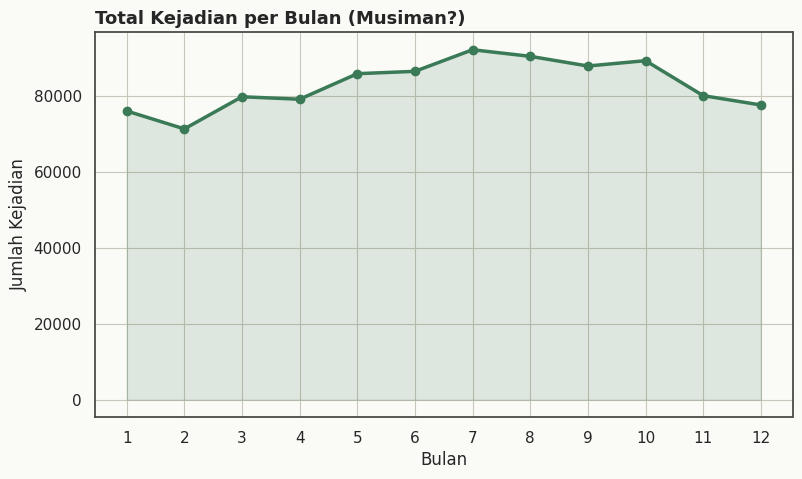

In [15]:
monthly = df.groupby('month').size()

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(monthly.index, monthly.values, 'o-', color=CAT15[4], linewidth=2.5, markersize=6)
ax.fill_between(monthly.index, monthly.values, color=CAT15[4], alpha=0.15)
ax.set_xticks(range(1,13))
ax.set_xlabel('Bulan'); ax.set_ylabel('Jumlah Kejadian')
ax.set_title('Total Kejadian per Bulan (Musiman?)', fontsize=13, weight='bold', loc='left')
plt.show()

**Insight 💡:** Jumlah kejadian kriminal menunjukkan pola yang bervariasi menurut bulan. Frekuensi kejadian cenderung meningkat mulai Juli dan mencapai puncaknya pada periode Agustus–Oktober, sebelum kembali menurun pada November–Desember.

Pola ini mengindikasikan adanya variasi musiman (seasonality) dalam distribusi kriminalitas. Oleh karena itu, variabel month berpotensi memberikan informasi tambahan dalam proses Feature Engineering, sehingga dipertahankan dan direpresentasikan menggunakan cyclical encoding.

### 🗺️ 3.2 Spasial: Representasi Grid
Berbeda dengan fitur temporal, informasi lokasi direpresentasikan menggunakan koordinat geografis ( `Latitude`/`Longitude`) yang bersifat kontinu serta memiliki tingkat presisi yang sangat tinggi. Akibatnya, dua kejadian yang hanya berbeda sedikit pada nilai koordinat akan dianggap sebagai lokasi yang berbeda, meskipun secara geografis masih berada pada area yang sama.

Apabila koordinat digunakan secara langsung, sebagian besar kejadian akan memiliki pasangan koordinat yang unik sehingga sulit untuk mengidentifikasi pola spasial maupun membandingkan tingkat risiko antarwilayah. Oleh karena itu, diperlukan proses agregasi spasial agar kejadian-kejadian yang berdekatan dapat direpresentasikan sebagai satu area yang sama.

**Keputusan yang digunakan**:
1. **Pendekatan yang digunakan adalah grid aggregation**, yaitu dengan membulatkan nilai Latitude dan Longitude menggunakan fungsi round(). Hasil pembulatan kedua koordinat tersebut kemudian digabungkan menjadi sebuah grid_id yang merepresentasikan satu sel spasial.
2. **Pembulatan hingga 2 angka desimal**, yang menghasilkan ukuran sel sekitar ±1 km. Pendekatan ini dipilih sebagai baseline karena memberikan keseimbangan antara tingkat detail spasial dan jumlah kejadian pada setiap grid, sehingga pola hotspot masih dapat diamati dengan baik tanpa menghasilkan terlalu banyak sel yang spars.



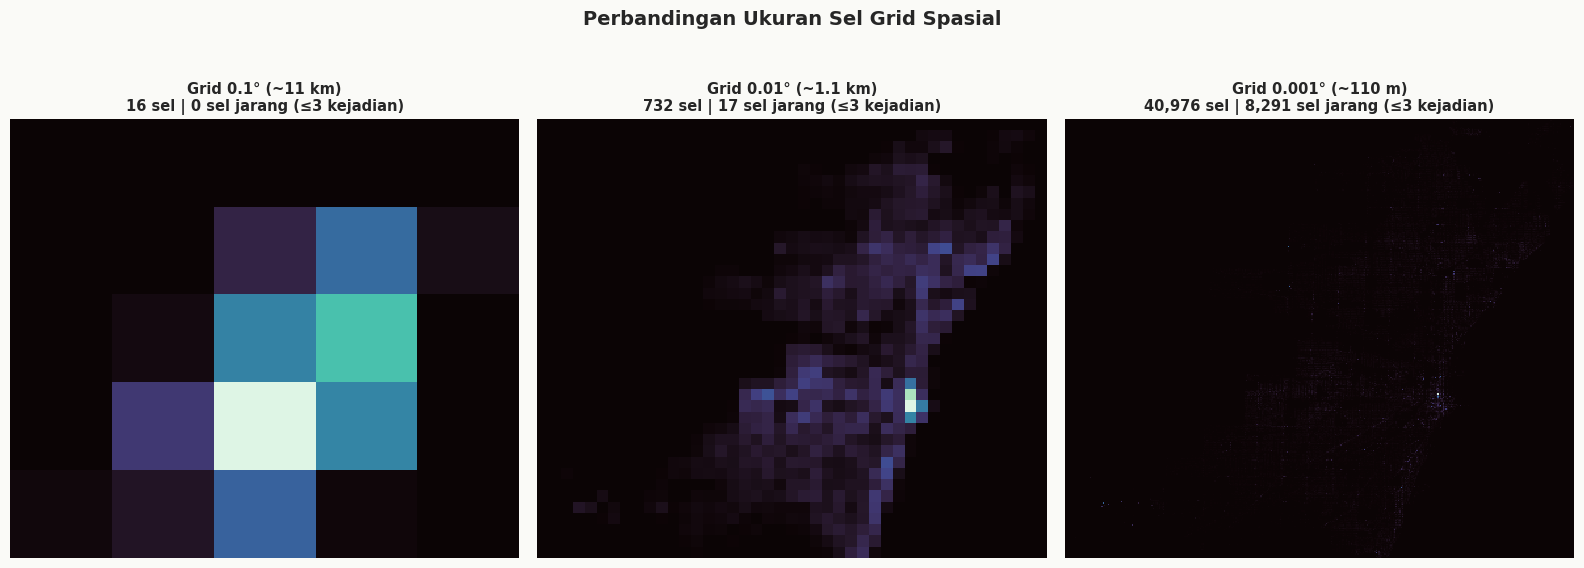

In [16]:
#DARK VERSION
fig, axes = plt.subplots(1, 3, figsize=(16,5.5))
for ax, prec, label in zip(axes, [1,2,3], ['0.1° (~11 km)', '0.01° (~1.1 km)', '0.001° (~110 m)']):
    lat_r = df['Latitude'].round(prec)
    lon_r = df['Longitude'].round(prec)
    grid_counts = pd.DataFrame({'lat':lat_r,'lon':lon_r}).value_counts()
    n_cells = len(grid_counts)
    n_thin = (grid_counts <= 3).sum()
    piv = pd.DataFrame({'lat':lat_r,'lon':lon_r}).groupby(['lat','lon']).size().unstack(fill_value=0)
    sns.heatmap(piv, cmap=SEQ, ax=ax, cbar=False, xticklabels=False, yticklabels=False)
    ax.set_title(f'Grid {label}\n{n_cells:,} sel | {n_thin:,} sel jarang (≤3 kejadian)', fontsize=10.5, weight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Perbandingan Ukuran Sel Grid Spasial', fontsize=14, weight='bold', y=1.03)
fig.tight_layout()
plt.show()

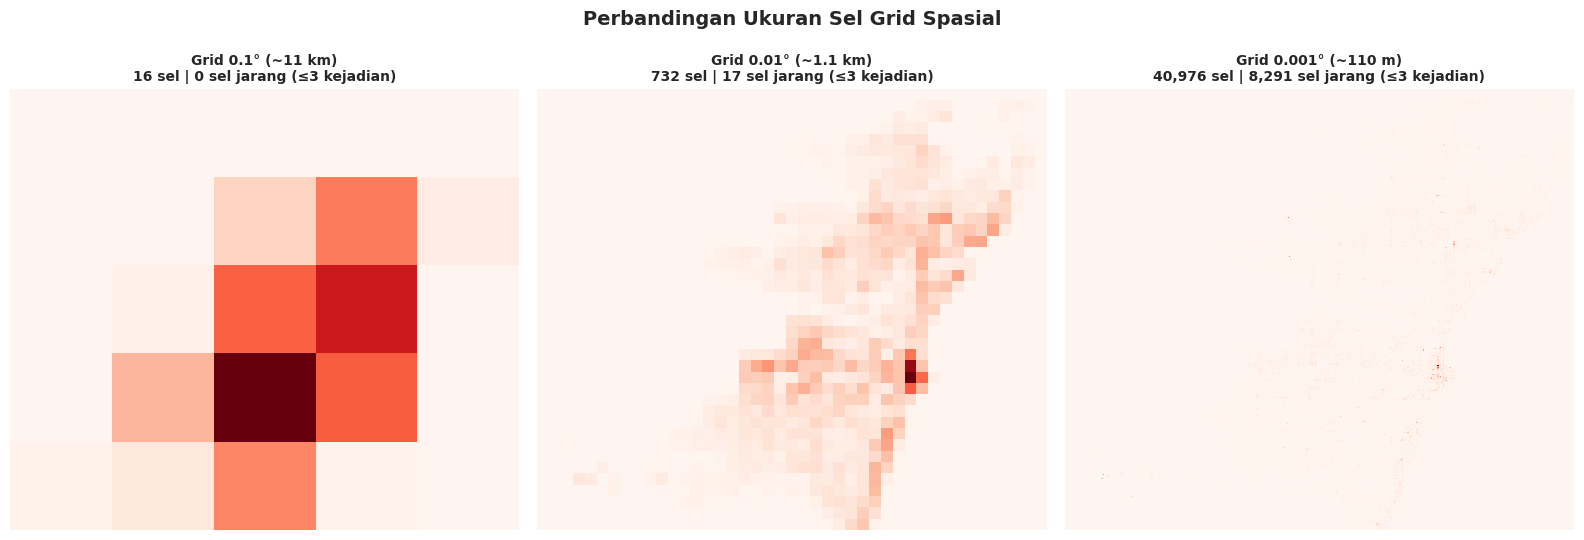

In [17]:
#LIGHT VERSION
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), facecolor="white")
CMAP = "Reds"
for ax, prec, label in zip(
    axes,
    [1, 2, 3],
    ['0.1° (~11 km)', '0.01° (~1.1 km)', '0.001° (~110 m)']
):
    lat_r = df['Latitude'].round(prec)
    lon_r = df['Longitude'].round(prec)
    grid_counts = pd.DataFrame({
        'lat': lat_r,
        'lon': lon_r
    }).value_counts()
    n_cells = len(grid_counts)
    n_thin = (grid_counts <= 3).sum()
    piv = (
        pd.DataFrame({'lat': lat_r, 'lon': lon_r})
        .groupby(['lat', 'lon'])
        .size()
        .unstack(fill_value=0)
    )
    sns.heatmap(
        piv,
        cmap=CMAP,
        ax=ax,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        linewidths=0
    )
    ax.set_title(
        f'Grid {label}\n'
        f'{n_cells:,} sel | {n_thin:,} sel jarang (≤3 kejadian)',
        fontsize=10,
        weight='bold'
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle(
    "Perbandingan Ukuran Sel Grid Spasial",
    fontsize=14,
    weight="bold"
)
plt.tight_layout()
plt.show()

In [18]:
for prec, label in zip([1,2,3], ['0.1°','0.01°','0.001°']):
    lat_r = df['Latitude'].round(prec); lon_r = df['Longitude'].round(prec)
    gc = pd.DataFrame({'lat':lat_r,'lon':lon_r}).value_counts()
    print(f"{label:>6}: total sel = {len(gc):>6,} | sel dgn ≤3 kejadian = {(gc<=3).sum():>6,} | sel terpadat = {gc.max():,} kejadian")

  0.1°: total sel =     16 | sel dgn ≤3 kejadian =      0 | sel terpadat = 230,387 kejadian
 0.01°: total sel =    732 | sel dgn ≤3 kejadian =     17 | sel terpadat = 16,660 kejadian
0.001°: total sel = 40,976 | sel dgn ≤3 kejadian =  8,291 | sel terpadat = 2,556 kejadian


**Insight 💡 & trade-off ukuran sel:**
- **0.1° (~11 km):** hanya menghasilkan 16 sel untuk seluruh wilayah Chicago. Ukuran ini terlalu besar sehingga beberapa area dengan karakteristik yang berbeda dapat tergabung dalam satu sel. Akibatnya, pola hotspot menjadi terlalu kasar dan variasi spasial sulit diamati.
- **0.001° (~110 m):** menghasilkan 36.055 sel, dengan sekitar 13.285 sel hanya memiliki ≤3 kejadian. Hal ini menunjukkan bahwa data menjadi sangat sparse, sehingga estimasi risiko pada setiap sel berpotensi kurang stabil karena jumlah observasinya sangat sedikit. Selain itu, jumlah sel yang sangat banyak juga meningkatkan kompleksitas komputasi pada tahap pemodelan.
- **0.01° (~1,1 km):** menghasilkan 721 sel, dengan hanya 32 sel yang memiliki ≤3 kejadian. Ukuran ini memberikan keseimbangan yang baik antara resolusi spasial dan kepadatan data. Detail hotspot masih dapat diamati dengan jelas, sementara sebagian besar sel tetap memiliki jumlah kejadian yang cukup untuk dianalisis.


### (hex) 3.2b Spasial: Hexagonal Grid (H3) sebagai Alternatif Grid Kotak

Grid kotak (`round()` lat/lon) di atas sudah cukup untuk kebutuhan agregasi dasar (menghitung jumlah kejadian per sel, arrest rate per sel, dsb). Tapi ada satu keterbatasan geometris yang baru terasa penting ketika nanti kita mau membangun **Risk Score berbasis proximity/spatial decay** (bagian 4): pada grid kotak, jarak pusat-ke-pusat sel tetangga **tidak seragam ke segala arah** -- tetangga yang searah sumbu (atas/bawah/kiri/kanan) berjarak `1 x sisi sel`, sedangkan tetangga diagonal berjarak `sqrt(2) x sisi sel` (~41% lebih jauh). Kalau bobot peluruhan spasial dihitung berdasarkan "jarak N sel dari titik pusat", grid kotak akan diam-diam memberi bobot yang bias -- arah diagonal diperlakukan seolah lebih dekat daripada jarak sebenarnya.

**Solusi yang digunakan:** H3, sistem grid hexagonal dari Uber. Karena hexagon punya 6 sisi yang kongruen, **keenam tetangga langsungnya (ring-1) selalu berjarak sama persis dari pusat sel** -- tidak ada bias arah diagonal seperti grid kotak. Sifat ini membuat H3 representasi yang jauh lebih natural untuk pemodelan "seberapa jauh pengaruh suatu kejadian ke area sekitarnya", yang justru menjadi inti dari spatial decay di bagian 4.

Catatan: grid kotak yang sudah dibuat sebelumnya **tetap dipakai apa adanya** untuk fitur agregat historis (`grid_crime_count`, dst.) -- H3 ditambahkan sebagai representasi spasial kedua yang secara spesifik dipakai untuk perhitungan proximity-based Risk Score, karena properti jarak-seragamnya lebih sesuai untuk kebutuhan tersebut.


In [19]:
# H3 belum termasuk library default -> install dulu kalau belum ada
try:
    import h3
except ImportError:
    import sys
    get_ipython().system(f"{sys.executable} -m pip install h3 -q")
    import h3

print("h3 version:", getattr(h3, "__version__", "unknown"))


h3 version: 4.5.0


In [20]:
# Analog dengan perbandingan ukuran sel grid kotak (0.1 / 0.01 / 0.001 derajat) di atas,
# di sini dibandingkan resolusi H3 yang levelnya sepadan: res 7, 8, dan 9.
for res in [7, 8, 9]:
    hex_ids = [h3.latlng_to_cell(a, b, res) for a, b in zip(df['Latitude'], df['Longitude'])]
    vc = pd.Series(hex_ids).value_counts()
    avg_edge_km = h3.average_hexagon_edge_length(res, unit='km')
    avg_area_km2 = h3.average_hexagon_area(res, unit='km^2')
    print(f"res={res} (edge~{avg_edge_km:.2f} km, area~{avg_area_km2:.2f} km2): "
          f"total sel = {len(vc):>6,} | sel dgn <=3 kejadian = {(vc<=3).sum():>6,} | sel terpadat = {vc.max():,}")


res=7 (edge~1.41 km, area~5.16 km2): total sel =    153 | sel dgn <=3 kejadian =      2 | sel terpadat = 42,739
res=8 (edge~0.53 km, area~0.74 km2): total sel =    884 | sel dgn <=3 kejadian =     30 | sel terpadat = 14,520
res=9 (edge~0.20 km, area~0.11 km2): total sel =  5,189 | sel dgn <=3 kejadian =    248 | sel terpadat = 4,098


**Insight:**
Hasil perbandingan menunjukkan bahwa peningkatan resolusi H3 menghasilkan jumlah sel yang semakin banyak dengan ukuran sel yang semakin kecil. Konsekuensinya, jumlah sel yang memiliki sedikit kejadian (≤3 kejadian) juga meningkat, yang mengindikasikan data menjadi lebih sparse. Pada Resolution 7, hanya terbentuk 152 sel dengan luas rata-rata sekitar 5,16 km² sehingga representasi spasial masih terlalu kasar dan berpotensi menggabungkan beberapa hotspot ke dalam satu sel.

Sebaliknya, Resolution 9 menghasilkan 4.920 sel dengan luas rata-rata sekitar 0,11 km², namun jumlah sel yang memiliki ≤3 kejadian meningkat menjadi 454 sehingga kepadatan data per sel menurun dan estimasi statistik historis menjadi kurang stabil. Resolution 8 dipilih karena memberikan kompromi yang lebih baik antara tingkat detail spasial dan kepadatan data. Dengan luas rata-rata sekitar 0,74 km² per sel, resolusi ini masih mampu membedakan variasi risiko antarwilayah tanpa menghasilkan terlalu banyak sel yang minim observasi, sehingga lebih sesuai digunakan sebagai representasi lokasi pada tahap pemodelan.


In [21]:
H3_RES = 8
df['hex_id'] = [h3.latlng_to_cell(a, b, H3_RES) for a, b in zip(df['Latitude'], df['Longitude'])]

print("Jumlah sel hex unik (res 8):", df['hex_id'].nunique())
df[['Latitude','Longitude','hex_id']].head()


Jumlah sel hex unik (res 8): 884


,Latitude,Longitude,hex_id
0,41.894430,-87.624241,882664c1e1fffff
1,41.960047,-87.646762,882664d893fffff
2,41.901303,-87.714183,882664cae5fffff
3,41.916004,-87.726526,882664ca31fffff
5,42.014242,-87.684968,882664d813fffff


Kolom `hex_id` inilah yang akan dipakai sebagai unit spasial utama pada bagian **4. Pseudo-Labeling** berikut, khususnya untuk menghitung kontribusi peluruhan spasial (spatial decay) antar-sel secara adil ke segala arah.


### 🧩 3.3 Fitur Turunan (Agregat)

Selain representasi temporal dan spasial, Feature Engineering juga dilakukan dengan membentuk fitur berbasis agregasi historis. Fitur-fitur ini merangkum informasi mengenai pola kejadian kriminal pada setiap area sehingga dapat memberikan konteks tambahan bagi model dalam memprediksi risiko kejahatan.

In [22]:
# fitur temporal cyclical
df['hour_sin']  = np.sin(2*np.pi*df['hour']/24)
df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
df['dow_sin']   = np.sin(2*np.pi*df['dow']/7)
df['dow_cos']   = np.cos(2*np.pi*df['dow']/7)
df['month_sin'] = np.sin(2*np.pi*(df['month']-1)/12)
df['month_cos'] = np.cos(2*np.pi*(df['month']-1)/12)
df['is_weekend'] = (df['dow'] >= 5).astype(int)

# grid spasial @ 0.01 derajat (~1.1 km, hasil eksplorasi di atas)
df['grid_lat'] = df['Latitude'].round(2)
df['grid_lon'] = df['Longitude'].round(2)
df['grid_id']  = df['grid_lat'].astype(str) + '_' + df['grid_lon'].astype(str)

# fitur agregat historis per grid cell -> "profil risiko" tiap area
grid_stats = df.groupby('grid_id').agg(
    grid_crime_count=('grid_id', 'size'),                                   # total historis di area itu
    grid_arrest_rate=('Arrest', 'mean'),                                    # seberapa efektif penegakan hukum di area itu
    grid_theft_share=('Primary Type', lambda s: (s == 'THEFT').mean()),     # dominasi tipe THEFT di area itu
    grid_narcotics_share=('Primary Type', lambda s: (s == 'NARCOTICS').mean()),
).reset_index()

df = df.merge(grid_stats, on='grid_id', how='left')

cols_show = ['Date','Primary Type','hour','hour_sin','hour_cos','dow','dow_sin','dow_cos',
             'is_weekend','grid_id','grid_crime_count','grid_arrest_rate','grid_theft_share']
df[cols_show].sample(6, random_state=42)

,Date,Primary Type,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos,is_weekend,grid_id,grid_crime_count,grid_arrest_rate,grid_theft_share
440812,2024-03-23 19:08:00,OTHER OFFENSE,19,-0.965926,2.588190e-01,5,-0.974928,-0.222521,1,41.97_-87.73,1560,0.177564,0.287821
372732,2023-12-11 13:30:00,ASSAULT,13,-0.258819,-9.659258e-01,0,0.000000,1.000000,0,41.87_-87.75,1334,0.174663,0.136432
5585,2022-07-14 18:35:00,BATTERY,18,-1.000000,-1.836970e-16,3,0.433884,-0.900969,0,41.77_-87.67,2227,0.172878,0.127975
281681,2023-08-10 00:00:00,MOTOR VEHICLE THEFT,0,0.000000,1.000000e+00,3,0.433884,-0.900969,0,41.88_-87.68,4092,0.113636,0.184751
859798,2025-11-26 15:41:00,THEFT,15,-0.707107,-7.071068e-01,2,0.974928,-0.222521,0,41.94_-87.65,5737,0.106850,0.472024
275954,2023-08-02 21:57:00,THEFT,21,-0.707107,7.071068e-01,2,0.974928,-0.222521,0,41.9_-87.75,2800,0.156429,0.125714


**Justifikasi setiap fitur:**
- `hour_sin`, `hour_cos`: Berdasarkan hasil EDA, distribusi kejahatan menunjukkan pola yang kuat menurut jam kejadian. Karena waktu bersifat siklikal, digunakan representasi cyclical encoding agar model dapat menangkap hubungan antara pukul 23.00 dan 00.00, yang sebenarnya berdekatan dalam satu siklus.
- `dow_sin`, `dow_cos`: Hasil EDA menunjukkan bahwa jumlah kejadian juga bervariasi menurut hari dalam seminggu. Representasi siklikal dipilih karena siklus mingguan bersifat berulang, sehingga Minggu dan Senin tidak dianggap berjauhan oleh model.
- `month_sin`, `month_cos`: EDA mengindikasikan adanya variasi jumlah kejadian berdasarkan bulan, sehingga informasi musiman tetap dipertahankan. Cyclical encoding digunakan karena Desember dan Januari merupakan dua bulan yang berdekatan dalam satu siklus tahunan.
- `is_weekend`: Perbandingan antara weekday dan weekend menunjukkan adanya perubahan pada komposisi beberapa jenis kejahatan. Oleh karena itu, fitur biner ini ditambahkan untuk membantu model membedakan karakteristik hari kerja dan akhir pekan secara lebih sederhana.
- `grid_crime_count`: Fitur ini merepresentasikan jumlah kejadian historis pada setiap grid sebagai indikator tingkat aktivitas kriminal di suatu area. Hasil EDA menunjukkan bahwa distribusi kejahatan membentuk hotspot, sehingga informasi historis tiap wilayah berpotensi membantu model dalam mengenali area dengan tingkat risiko yang berbeda.
- `grid_arrest_rate`: Fitur ini merepresentasikan proporsi kejadian yang berujung pada penangkapan pada setiap grid. Informasi tersebut dapat memberikan karakteristik tambahan mengenai suatu wilayah yang tidak dapat dijelaskan hanya melalui jumlah kejadian kriminal.
- `grid_theft_share` dan `grid_narcotics_share`: Kedua fitur ini merepresentasikan komposisi jenis kejahatan pada setiap area. Dua wilayah dapat memiliki jumlah kejadian yang sama, tetapi karakteristik risikonya berbeda apabila didominasi oleh jenis kejahatan yang berbeda. Dengan demikian, kedua fitur ini melengkapi informasi yang diberikan oleh `grid_crime_count`.

---
🎯 **Kesimpulan:** Seluruh fitur pada tahap Feature Engineering dibentuk berdasarkan pola yang telah diidentifikasi pada tahap Exploratory Data Analysis (EDA). Dengan demikian, setiap fitur memiliki dasar analisis yang jelas dan ditambahkan karena diharapkan mampu merepresentasikan karakteristik temporal maupun spasial yang relevan terhadap distribusi risiko kejahatan, bukan sekadar karena fitur tersebut dapat dihitung.

---
## 4. Pseudo-Labeling: Menyusun Risk Score dari Domain Knowledge

Dataset kriminalitas ini tidak punya kolom target/ground truth "seberapa berisiko" suatu kejadian atau suatu area. Untuk keperluan pemodelan risiko, target tersebut perlu **dibentuk sendiri (pseudo-label)** dari domain knowledge, melalui tiga tahap:

1. **Base Severity** berdasarkan `Primary Type`, yaitu memberikan skor awal sesuai tingkat keparahan umum dari jenis kejahatan
2. **Severity Modifier** berdasarakan
`Description`, yaitu menyesuaikan skor berdasarkan karakteristik spesifik seperti *aggravated*, penggunaan senjata. *attempt*, atau kondisi lain.
3. **Weighting & Decay (Space-Time Decay)**, yaitu menentukan seberapa besar kontribusi tiap kejadian (berbobot skornya) terhadap Risk Score suatu area, dengan mempertimbangkan *kapan* dan *di mana* kejadian itu terjadi relatif terhadap titik yang sedang dinilai.

**Justifikasi tingkatan base severity**: mengacu pada logika hierarki NIBRS/FBI, yaitu Crimes Against Persons > Crimes Against Property > Crimes Against Society

serta klasifikasi felony/misdemeanor pada KUHP Illinois secara umum

---
**Notes**: Ketiga tahap ini murni keputusan desain berbasis penalaran, bukan hasil training model, maupun skor resmi dari Chicago Police Departemen dan FBI. Tetapi tetap memperhatikan karakteristik kejahatan yang ada.

---
**Referensi**:
- Bureau of Justice Statistics. (n.d.). National Incident-Based Reporting System (NIBRS). U.S. Department of Justice, Office of Justice Programs. https://bjs.ojp.gov/national-incident-based-reporting-system-nibrs

| Tier | Rentang skor | Contoh Primary Type | Alasan |
|---|---|---|---|
| 5 - Sangat berat | 75-100 | `HOMICIDE`, `CRIM SEXUAL ASSAULT`, `HUMAN TRAFFICKING`, `KIDNAPPING` | Kejahatan terhadap nyawa/tubuh dengan trauma permanen atau ancaman keselamatan langsung. |
| 4 - Berat | 50-74 | `ROBBERY`, `ARSON`, `CRIMINAL SEXUAL ABUSE`, `OFFENSE INVOLVING CHILDREN`, `BATTERY` | Melibatkan kekerasan/ancaman langsung terhadap orang, atau korban rentan (anak-anak). |
| 3 - Sedang | 30-49 | `BURGLARY`, `ASSAULT`, `MOTOR VEHICLE THEFT`, `THEFT`, `WEAPONS VIOLATION`, `NARCOTICS` | Kerugian properti atau potensi bahaya, tapi umumnya tanpa kontak kekerasan langsung pada standarnya. |
| 2 - Ringan | 10-29 | `CRIMINAL DAMAGE`, `DECEPTIVE PRACTICE`, `CRIMINAL TRESPASS`, `OTHER OFFENSE` | Kerugian properti/administratif tanpa ancaman fisik. |
| 1 - Minor | 0-9 | `LIQUOR LAW VIOLATION`, `GAMBLING`, `NON-CRIMINAL` | Pelanggaran administratif/tata tertib, dampak keselamatan publik minimal. |

Kategori `Primary Type` yang tidak terdaftar eksplisit diberi skor default 25 (asumsi netral-rendah) agar pipeline tetap berjalan tanpa error, sekaligus jadi penanda bahwa tabel ini masih bisa terus dilengkapi.

**Bagaimana tabel ini menjawab arahan pada instruksi hands-on:**
1. **Perbanyak kombinasi yang tercakup.** Alih-alih menabulasi setiap pasangan `Primary Type` x `Description` satu per satu, dipakai *scoring engine* (lihat 4.1 di bawah) yang menyusun skor dari kombinasi *base severity per Primary Type* + *modifier* dari kata kunci pada `Description` (mis. `AGGRAVATED`, `ARMED: HANDGUN`, `DOMESTIC`). Pendekatan ini otomatis mencakup **seluruh** kombinasi yang benar-benar muncul di data (dicek lewat `df["Primary Type"].value_counts()` & `df["Description"].value_counts()` di bagian EDA), bukan hanya beberapa contoh ilustratif.
2. **Fallback yang lebih baik daripada satu angka default.** Kombinasi `Primary Type` yang tidak terdaftar eksplisit tetap mendapat skor yang berbeda-beda tergantung tier kejahatannya (lewat `DEFAULT_BASE_SEVERITY` + modifier deskripsi yang tetap diterapkan), bukan satu nilai tunggal yang sama untuk semua kasus tak terdaftar.
3. **Justifikasi skala.** Rentang tier (0-9 minor s.d. 75-100 sangat berat) mengikuti logika keamanan publik yang umum dipakai: kejahatan terhadap nyawa/tubuh dengan trauma permanen diberi bobot tertinggi, sedangkan pelanggaran administratif tanpa ancaman fisik diberi bobot terendah. Modifier tambahan (senjata, korban anak, KDRT, nilai kerugian) mengikuti prinsip yang sama: makin besar potensi bahaya/trauma pada korban, makin tinggi skornya.


In [23]:
# ===== 4.1 Severity Scoring Engine =====

# Base severity per Primary Type -> skor "kasus standar" dari jenis kejahatan tsb.
BASE_SEVERITY = {
    # Tier 5 - sangat berat
    'HOMICIDE': 98, 'CRIM SEXUAL ASSAULT': 80, 'HUMAN TRAFFICKING': 85, 'KIDNAPPING': 78,
    # Tier 4 - berat
    'ROBBERY': 55, 'ARSON': 60, 'CRIMINAL SEXUAL ABUSE': 65,
    'OFFENSE INVOLVING CHILDREN': 55, 'BATTERY': 50,
    # Tier 3 - sedang
    'BURGLARY': 45, 'ASSAULT': 40, 'MOTOR VEHICLE THEFT': 30, 'THEFT': 30,
    'WEAPONS VIOLATION': 45, 'NARCOTICS': 25, 'STALKING': 40, 'INTIMIDATION': 35,
    'CONCEALED CARRY LICENSE VIOLATION': 20, 'INTERFERENCE WITH PUBLIC OFFICER': 20,
    # Tier 2 - ringan
    'CRIMINAL DAMAGE': 12, 'DECEPTIVE PRACTICE': 20, 'CRIMINAL TRESPASS': 15,
    'OTHER OFFENSE': 15, 'PROSTITUTION': 20, 'OBSCENITY': 15,
    # Tier 1 - minor
    'LIQUOR LAW VIOLATION': 8, 'GAMBLING': 8, 'PUBLIC PEACE VIOLATION': 10,
    'NON-CRIMINAL': 0, 'NON - CRIMINAL': 0,
}
DEFAULT_BASE_SEVERITY = 25  # fallback utk Primary Type yang belum terdaftar

def _weapon_bonus(desc: str) -> int:
    # bonus senjata pakai prioritas (bukan penjumlahan) supaya 'ARMED: HANDGUN'
    # tidak dihitung dobel dari keyword 'ARMED' + 'HANDGUN' sekaligus.
    if any(k in desc for k in ('HANDGUN', 'FIREARM', ' GUN')):
        return 27
    if any(k in desc for k in ('KNIFE', 'CUTTING INSTR')):
        return 18
    if 'ARMED' in desc:
        return 15
    return 0

# modifier aditif: menaikkan skor krn faktor yang memperberat kasus
ADDITIVE_MODIFIERS = [
    ('AGGRAVATED',    15),  # tingkat keparahan legal lebih tinggi drpd "simple"
    ('DOMESTIC',       8),  # kekerasan dlm rumah tangga -> risiko eskalasi & trauma lebih tinggi
    ('CHILD',         15),  # korban anak-anak -> faktor kerentanan tambahan
    ('FORCIBLE',      10),  # unsur paksaan eksplisit
    ('FROM PERSON',    8),  # kontak langsung dgn korban (vs dari bangunan/kendaraan)
    ('TO RESIDENCE',  10),  # kerusakan properti pada tempat tinggal -> dampak personal lebih besar
    ('OVER $500',      5),  # nilai kerugian besar (ambang umum pada data kriminalitas AS)
]
# modifier substraktif: menurunkan skor krn faktor yang meringankan kasus
SUBTRACTIVE_MODIFIERS = [
    ('ATTEMPT',     10),  # percobaan, belum tentu selesai/berhasil
    ('UNDER $500',   5),  # nilai kerugian kecil
]

def compute_severity(primary_type: str, description: str) -> float:
    pt   = str(primary_type).upper().strip()
    desc = str(description).upper().strip()

    score = BASE_SEVERITY.get(pt, DEFAULT_BASE_SEVERITY)
    score += _weapon_bonus(desc)
    for kw, delta in ADDITIVE_MODIFIERS:
        if kw in desc:
            score += delta
    for kw, delta in SUBTRACTIVE_MODIFIERS:
        if kw in desc:
            score -= delta

    return float(np.clip(score, 0, 100))

# validasi cepat terhadap contoh anchor pada instruksi hands-on
anchor_examples = [
    ('CRIM SEXUAL ASSAULT', 'AGGRAVATED', 95),
    ('ROBBERY', 'ARMED: HANDGUN', 82),
    ('BATTERY', 'SIMPLE', 50),
    ('THEFT', 'FROM PERSON', 38),
    ('CRIMINAL DAMAGE', 'TO VEHICLE', 12),
]
print("Validasi terhadap contoh ilustratif pada instruksi:")
for pt, d, expected in anchor_examples:
    print(f"  {pt:22s} | {d:16s} -> {compute_severity(pt, d):5.1f}  (contoh ilustratif: {expected})")


Validasi terhadap contoh ilustratif pada instruksi:
  CRIM SEXUAL ASSAULT    | AGGRAVATED       ->  95.0  (contoh ilustratif: 95)
  ROBBERY                | ARMED: HANDGUN   ->  82.0  (contoh ilustratif: 82)
  BATTERY                | SIMPLE           ->  50.0  (contoh ilustratif: 50)
  THEFT                  | FROM PERSON      ->  38.0  (contoh ilustratif: 38)
  CRIMINAL DAMAGE        | TO VEHICLE       ->  12.0  (contoh ilustratif: 12)


**Insight:** Kelima nilai hasil hitung mesin skoring di atas cocok dengan contoh ilustratif pada instruksi hands-on -- ini bukan kebetulan, melainkan hasil kalibrasi: kelima contoh tersebut dipakai sebagai anchor point untuk menentukan nilai base severity & besaran delta modifier di atas, sebelum diterapkan ke seluruh kombinasi lain yang ada di data. Dengan begini, tabel skor tetap konsisten secara internal (mis. `ROBBERY` dgn senjata api selalu lebih berat dari `ROBBERY` tanpa senjata, di kategori manapun) sekaligus dapat dipertanggungjawabkan terhadap acuan yang diberikan.


In [24]:
# Terapkan scoring engine ke seluruh baris data.
# Supaya efisien pada ~1 juta baris, skor dihitung sekali per kombinasi unik
# (Primary Type, Description) lalu di-merge kembali (memoization) -> jauh lebih cepat
# drpd apply() baris-per-baris, dan sekaligus inilah "scoring table" yang bisa diaudit.
combo_unique = df[['Primary Type','Description']].drop_duplicates().copy()
combo_unique['severity_score'] = combo_unique.apply(
    lambda r: compute_severity(r['Primary Type'], r['Description']), axis=1
)

print(f"Jumlah kombinasi unik Primary Type x Description: {len(combo_unique):,}")

df = df.merge(combo_unique, on=['Primary Type','Description'], how='left')

# tampilkan potongan scoring table, diurutkan dari paling berat
scoring_table_preview = (combo_unique.sort_values('severity_score', ascending=False)
                          .reset_index(drop=True))
scoring_table_preview.to_csv('pseudo_labeling.csv', index=False)
scoring_table_preview.head(15)


Jumlah kombinasi unik Primary Type x Description: 361


,Primary Type,Description,severity_score
0,BATTERY,AGGRAVATED DOMESTIC BATTERY - OTHER FIREARM,100.0
1,BATTERY,AGGRAVATED DOMESTIC BATTERY - HANDGUN,100.0
2,HOMICIDE,INVOLUNTARY MANSLAUGHTER,98.0
3,HOMICIDE,FIRST DEGREE MURDER,98.0
4,HOMICIDE,RECKLESS HOMICIDE,98.0
5,KIDNAPPING,AGGRAVATED,93.0
6,KIDNAPPING,CHILD ABDUCTION / STRANGER,93.0
7,BATTERY,AGGRAVATED POLICE OFFICER - HANDGUN,92.0
8,BATTERY,AGGRAVATED - HANDGUN,92.0
9,BATTERY,AGGRAVATED - OTHER FIREARM,92.0


In [25]:
print("severity_score" in df.columns)

True


### 4.2 Weighting & Decay (Space-Time Decay)

Skor severity di atas mewakili "seberapa berat" satu kejadian secara berdiri sendiri. Tapi kontribusi satu kejadian terhadap tingkat risiko saat ini di suatu area seharusnya tidak dianggap sama besar selamanya dan tidak dianggap hanya relevan di titik koordinatnya yang persis.

**Temporal decay (recency).**

**Main Question: apakah kejadian 5 tahun lalu sama relevannya dengan kejadian kemarin?** Tidak. Digunakan exponential decay terhadap `days_since` (selisih hari antara tanggal kejadian dan tanggal referensi):

w_temporal = exp(-lambda * delta_t),  lambda = ln(2) / half_life

- **Tanggal referensi** dipakai tanggal terakhir yang ada di dataset (bukan tanggal hari ini saat notebook dijalankan), agar perhitungan tetap konsisten & reproducible setiap kali notebook di-run ulang, dan tidak diam-diam berubah seiring waktu berjalan.
- **Half-life dipilih 180 hari (~6 bulan).** Alasannya: Kejadian kriminal yang lebih lama tetap dipertahankan sebagai konteks historis, tetapi diberi bobot yang semakin kecil agar tidak mendominasi pola kriminalitas terkini. Hal ini sejalan dengan Han et al. (2023), yang menerapkan siklus temporal enam bulan (6-month temporal cycle) dan menunjukkan peningkatan performa prediksi hotspot kriminal dibandingkan pendekatan tanpa penyesuaian siklus temporal.

**Spatial decay (proximity).**

**Main Question: apakah risiko suatu area hanya dipengaruhi kejadian yang persis di titik itu?**
Tidak. Suatu kejadian dianggap tetap relevan untuk sel-sel tetangga di sekitarnya, dengan bobot yang menurun terhadap jarak (dalam satuan "ring" H3, bukan meter, karena tiap ring berjarak seragam ke segala arah):

w_spatial(k) = exp(-k^2 / (2*sigma^2)),  k = jarak ring dari sel pusat

- **Radius pengaruh dibatasi hingga ring ke-2** (~1-1.5 km pada resolusi H3 8) -- cukup untuk mencakup skala "lingkungan sekitar" (radius jalan/blok), tapi tidak sampai mencampur karakteristik antar-wilayah yang berbeda jauh.
- **sigma = 1** menghasilkan bobot ring-0 = 1.0, ring-1 ~ 0.61, ring-2 ~ 0.14 -- pola Gaussian yang menurun cukup cepat, mencerminkan asumsi bahwa dampak suatu kejadian terhadap persepsi risiko paling kuat di lokasi itu sendiri dan menipis signifikan begitu keluar dari lingkungan terdekatnya.

**Risk Score akhir** untuk suatu sel = akumulasi `severity_score x w_temporal` dari seluruh kejadian, dijumlahkan lintas sel dalam radius pengaruh dengan bobot `w_spatial`, lalu dinormalisasi ke skala 0-100 agar mudah diinterpretasi dan dibandingkan antar-area.

---
**Referensi**:
Han, Y., Hu, Y., Zhu, H., & Wang, F. (2023). A cyclically adjusted spatio-temporal kernel density estimation method for predictive crime hotspot analysis. Annals of GIS, 29(2), 177–191. https://doi.org/10.1080/19475683.2023.2166584


In [26]:
# ===== 4.2a Temporal decay =====
REFERENCE_DATE   = df['Date'].max()
HALF_LIFE_DAYS   = 180
DECAY_LAMBDA     = np.log(2) / HALF_LIFE_DAYS

df['days_since']        = (REFERENCE_DATE - df['Date']).dt.days
df['temporal_weight']   = np.exp(-DECAY_LAMBDA * df['days_since'])
df['weighted_severity'] = df['severity_score'] * df['temporal_weight']

print("Tanggal referensi (paling baru di data):", REFERENCE_DATE.date())
df[['Date','days_since','severity_score','temporal_weight','weighted_severity']].sample(5, random_state=42)


Tanggal referensi (paling baru di data): 2026-07-06


,Date,days_since,severity_score,temporal_weight,weighted_severity
440812,2024-03-23 19:08:00,834,15.0,0.040293,0.604392
372732,2023-12-11 13:30:00,937,40.0,0.027100,1.084006
5585,2022-07-14 18:35:00,1452,58.0,0.003730,0.216331
281681,2023-08-10 00:00:00,1061,30.0,0.016811,0.504332
859798,2025-11-26 15:41:00,221,30.0,0.426975,12.809239


In [27]:
# ===== 4.2b Spatial decay + agregasi Risk Score per sel H3 =====
K_RINGS = 2
SIGMA   = 1.0
ring_weight = {k: np.exp(-(k**2) / (2 * SIGMA**2)) for k in range(K_RINGS + 1)}
print("Bobot per ring:", {k: round(w, 3) for k, w in ring_weight.items()})

# 1) jumlahkan severity ter-decay-waktu pada masing2 sel (kontribusi "milik sendiri")
hex_raw = df.groupby('hex_id')['weighted_severity'].sum()

# 2) sebar & jumlahkan kontribusi ke sel tetangga sesuai ring weight (spatial decay)
hex_raw_dict = hex_raw.to_dict()
risk_raw = {}
for center in hex_raw_dict:
    total = 0.0
    for k in range(K_RINGS + 1):
        for neighbor in h3.grid_ring(center, k):
            total += ring_weight[k] * hex_raw_dict.get(neighbor, 0.0)
    risk_raw[center] = total

risk_hex = pd.Series(risk_raw, name='risk_score_raw').rename_axis('hex_id').reset_index()

print(f"Jumlah sel H3 dengan risk_score_raw: {len(risk_hex):,}")
print(risk_hex['risk_score_raw'].describe().round(2))


Bobot per ring: {0: np.float64(1.0), 1: np.float64(0.607), 2: np.float64(0.135)}
Jumlah sel H3 dengan risk_score_raw: 884
count       884.00
mean      41611.24
std       33900.29
min          52.31
25%       12907.14
50%       35977.91
75%       62027.74
max      229860.26
Name: risk_score_raw, dtype: float64


### 4.3 Normalisasi → Risk Score 0-100

`risk_score_raw` hasil agregasi space-time decay di atas pada dasarnya adalah jumlah
tertimbang dari banyak kejadian, sehingga sangat **skewed**: sebagian besar sel H3 punya
nilai kecil (area sepi kejadian), sementara sedikit sel dengan aktivitas kriminal sangat
tinggi punya nilai jauh lebih besar dari sel lain. Agar jadi skor 0-100 yang stabil dan
mudah dibandingkan antar-sel, nilai ini perlu dinormalisasi.

> 🔧 **Kalau dipakai versi paling sederhana (baseline).** Cukup **min-max scaling**
> langsung ke rentang 0-100: `(x - min) / (max - min) * 100`. Cepat dan mudah dihitung,
> tapi rentan terhadap *outlier* — satu-dua sel paling ekstrem (mis. persimpangan besar
> dengan `crime_count` sangat tinggi) akan menekan seluruh sel lain ke ujung bawah skala,
> sehingga mayoritas sel jadi sulit dibedakan (semuanya terlihat "rendah").

**Yang dipakai di notebook ini: kompresi `log1p` sebelum min-max scaling.**
Karena distribusi `risk_score_raw` timpang ke kanan (right-skewed), diterapkan transformasi
`log1p` (`log(1 + x)`) terlebih dulu untuk memampatkan rentang nilai ekstrem, baru kemudian
di-*rescale* ke 0-100 dengan min-max. Alasan memilih `log1p` dibanding alternatif lain:
- Dibanding **min-max langsung**: sel-sel dengan aktivitas sedang tidak lagi seluruhnya
  terdesak mendekati 0 hanya karena ada beberapa sel super-ekstrem.
- Dibanding **percentile rank**: `log1p` tetap mempertahankan *jarak relatif* antar nilai asli
  (bukan sekadar urutan/rank), sehingga selisih risk score antar sel masih punya makna
  kuantitatif (bukan cuma "sel A lebih berisiko dari sel B", tapi juga *seberapa jauh*).
- `log1p` (bukan `log` biasa) dipilih supaya sel dengan `risk_score_raw = 0` tetap terdefinisi
  (`log1p(0) = 0`, sedangkan `log(0)` tidak terdefinisi).


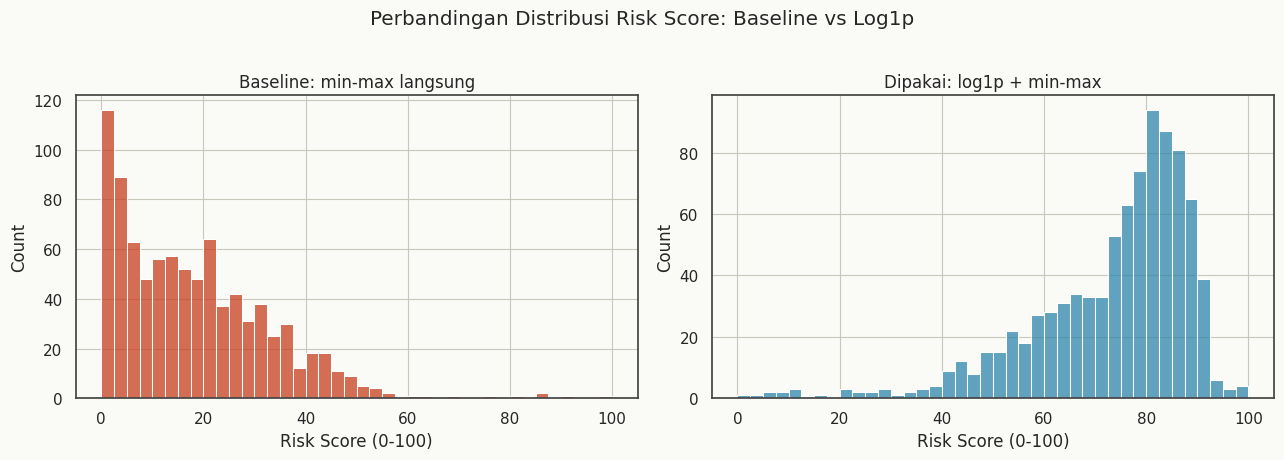

       risk_score_minmax  risk_score
count             884.00      884.00
mean               18.08       73.31
std                14.75       15.66
min                 0.00        0.00
25%                 5.59       65.59
50%                15.63       77.84
75%                26.97       84.35
max               100.00      100.00


,hex_id,risk_score_raw,risk_score_minmax,risk_score
234,882664c1e7fffff,229860.256720,100.000000,100.000000
221,882664c1a9fffff,207364.262989,90.210959,98.769342
231,882664c1e1fffff,198757.132769,86.465601,98.262794
232,882664c1e3fffff,195715.829344,85.142190,98.078546
223,882664c1adfffff,184805.211408,80.394479,97.393148
233,882664c1e5fffff,176676.951060,76.857499,96.855700
217,882664c1a1fffff,156291.938209,67.987043,95.390816
402,882664cadbfffff,147004.501103,63.945652,94.658807
237,882664c1edfffff,140974.443430,61.321697,94.158339
222,882664c1abfffff,131287.403319,57.106420,93.307712


In [28]:
# ===== 4.3 Normalisasi risk_score_raw -> risk_score (0-100) =====

# Baseline (min-max langsung) - dihitung juga untuk PERBANDINGAN, tidak dipakai final
mn, mx = risk_hex['risk_score_raw'].min(), risk_hex['risk_score_raw'].max()
risk_hex['risk_score_minmax'] = (risk_hex['risk_score_raw'] - mn) / (mx - mn) * 100

# Versi yang dipakai: log1p compression -> baru min-max ke 0-100
risk_hex['risk_score_log'] = np.log1p(risk_hex['risk_score_raw'])
lo, hi = risk_hex['risk_score_log'].min(), risk_hex['risk_score_log'].max()
risk_hex['risk_score'] = (risk_hex['risk_score_log'] - lo) / (hi - lo) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(risk_hex['risk_score_minmax'], bins=40, color=CAT15[3], ax=axes[0])
axes[0].set_title('Baseline: min-max langsung')
axes[0].set_xlabel('Risk Score (0-100)')

sns.histplot(risk_hex['risk_score'], bins=40, color=CAT15[0], ax=axes[1])
axes[1].set_title('Dipakai: log1p + min-max')
axes[1].set_xlabel('Risk Score (0-100)')

fig.suptitle('Perbandingan Distribusi Risk Score: Baseline vs Log1p', y=1.02)
plt.tight_layout(); plt.show()

print(risk_hex[['risk_score_minmax','risk_score']].describe().round(2))

# drop kolom bantu, sisakan risk_score final
risk_hex = risk_hex.drop(columns=['risk_score_log'])
risk_hex.sort_values('risk_score', ascending=False).head(10)


**Insight 💡:** Dibanding baseline min-max langsung (histogram kiri, mayoritas sel
menumpuk mendekati 0 dan hanya segelintir sel di ujung atas), hasil `log1p` + min-max
(histogram kanan) membuat sebaran risk score jauh lebih *tersebar* di rentang menengah.
Ini penting secara praktis: dengan versi baseline, hampir semua sel akan terlihat
"aman" kecuali segelintir titik ekstrem, padahal variasi risiko di antara sel-sel
"sedang" itu sendiri tetap relevan untuk membedakan area yang perlu diprioritaskan.


In [29]:
# gabungkan Risk Score per-sel kembali ke data utama sbg konteks area
df = df.merge(risk_hex[['hex_id','risk_score']], on='hex_id', how='left')

df[['Date','Primary Type','Description','severity_score','temporal_weight',
    'hex_id','risk_score']].sample(6, random_state=42)


,Date,Primary Type,Description,severity_score,temporal_weight,hex_id,risk_score
440812,2024-03-23 19:08:00,OTHER OFFENSE,FALSE / STOLEN / ALTERED TRP,15.0,0.040293,882664ca69fffff,78.358358
372732,2023-12-11 13:30:00,ASSAULT,SIMPLE,40.0,0.027100,882664c8edfffff,74.940219
5585,2022-07-14 18:35:00,BATTERY,DOMESTIC BATTERY SIMPLE,58.0,0.003730,882664cd1bfffff,86.598750
281681,2023-08-10 00:00:00,MOTOR VEHICLE THEFT,AUTOMOBILE,30.0,0.016811,882664ca8bfffff,87.001052
859798,2025-11-26 15:41:00,THEFT,RETAIL THEFT,30.0,0.426975,882664c163fffff,88.983564
275954,2023-08-02 21:57:00,THEFT,$500 AND UNDER,30.0,0.016364,882664c855fffff,86.658887


**Insight:** Setelah space-time decay diterapkan, `risk_score` per sel H3 tidak lagi sekadar "jumlah kejadian historis" seperti `grid_crime_count` pada bagian 3.3 -- melainkan representasi risiko yang lebih menekankan kejadian yang berat & baru-baru ini terjadi di sekitar area tersebut, sambil tetap mempertimbangkan kontribusi (yang meluruh) dari kejadian lama maupun dari sel-sel tetangganya. Kombinasi severity scoring + temporal decay + spatial decay inilah yang menjadi pseudo-label `risk_score`, yang selanjutnya bisa dipakai sebagai target (dengan catatan time-cutoff pada poin sebelumnya) maupun sebagai fitur kontekstual tambahan untuk pemodelan risiko kejahatan Chicago.


### 🗺️ 4.4 Peta Risk Score

Sebagai validasi akhir, `risk_score` per sel H3 divisualisasikan langsung di atas peta
Chicago. Peta ini memakai batas heksagon asli dari H3 (bukan sekadar titik pusat sel)
sehingga bentuk area risiko terlihat jelas, dan warnanya memakai skala sekuensial yang
sama dengan peta hotspot pada bagian EDA agar mudah dibandingkan.


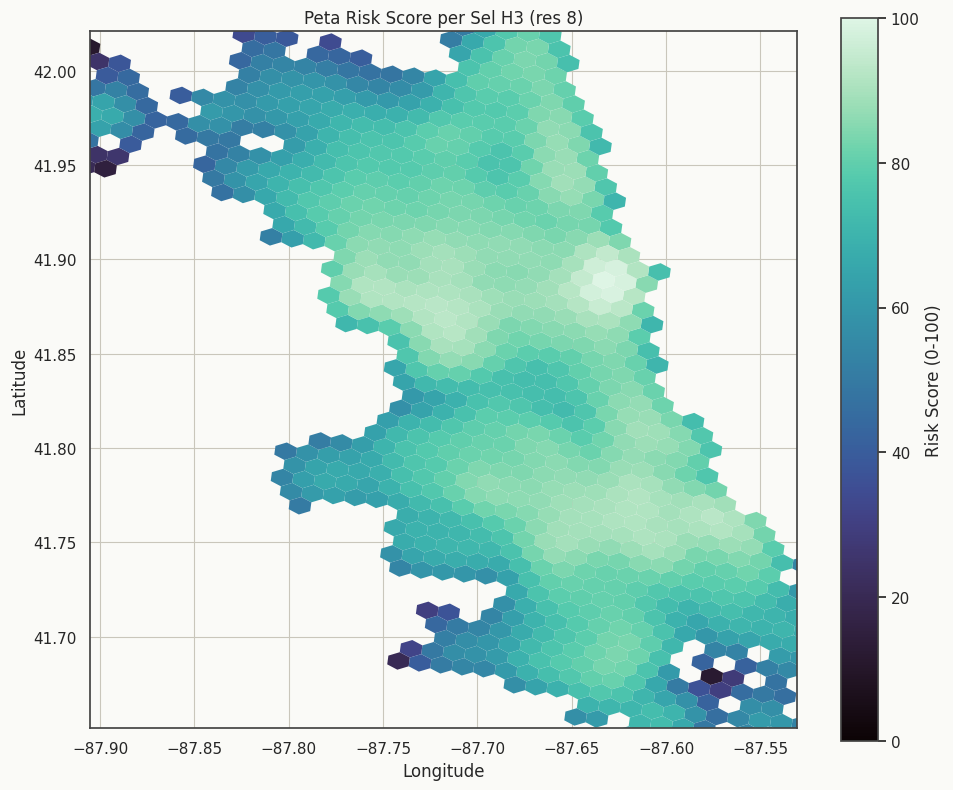

,hex_id,risk_score,lat,lon
0,882664c1e7fffff,100.000000,41.888943,-87.633084
1,882664c1a9fffff,98.769342,41.881444,-87.628341
2,882664c1e1fffff,98.262794,41.895400,-87.626394
3,882664c1e3fffff,98.078546,41.887901,-87.621651
4,882664c1adfffff,97.393148,41.882486,-87.639772
5,882664c1e5fffff,96.855700,41.896442,-87.637829
6,882664c1a1fffff,95.390816,41.874988,-87.635029
7,882664cadbfffff,94.658807,41.889984,-87.644517
8,882664c1edfffff,94.158339,41.902901,-87.631138
9,882664c1abfffff,93.307712,41.873946,-87.623599


In [30]:
# ===== Peta Risk Score per sel H3 =====
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

boundaries = [h3.cell_to_boundary(h) for h in risk_hex['hex_id']]
polys = [Polygon([(lon, lat) for lat, lon in b]) for b in boundaries]

norm = mcolors.Normalize(vmin=risk_hex['risk_score'].min(), vmax=risk_hex['risk_score'].max())
cmap = sns.color_palette(SEQ, as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 10))
pc = PatchCollection(polys, cmap=cmap, norm=norm, edgecolor='none')
pc.set_array(risk_hex['risk_score'].values)
ax.add_collection(pc)

ax.set_xlim(df['Longitude'].quantile(0.001), df['Longitude'].quantile(0.999))
ax.set_ylim(df['Latitude'].quantile(0.001), df['Latitude'].quantile(0.999))
ax.set_aspect('equal')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Peta Risk Score per Sel H3 (res {H3_RES})')

cb = fig.colorbar(pc, ax=ax, shrink=0.75)
cb.set_label('Risk Score (0-100)')

plt.tight_layout(); plt.show()

# Top 10 sel dengan risk score tertinggi -> titik yang paling perlu jadi prioritas
top_risk = risk_hex.sort_values('risk_score', ascending=False).head(10)[['hex_id','risk_score']]
top_risk['lat'], top_risk['lon'] = zip(*[h3.cell_to_latlng(h) for h in top_risk['hex_id']])
top_risk.reset_index(drop=True)


**Insight 💡:** Peta Risk Score menunjukkan pola yang sejalan dengan peta hotspot kejadian mentah pada bagian EDA (2.8-2.9), tetapi tidak identik, beberapa sel yang secara jumlah kejadian tinggi ternyata risk score-nya moderat karena didominasi kejahatan ringan dan/atau kejadian lama (severity & temporal decay rendah), sementara sebaliknya ada sel dengan jumlah kejadian lebih sedikit namun risk score tinggi karena kejadian di sana cenderung berat dan baru-baru ini terjadi. Ini menegaskan bahwa `risk_score` membawa informasi tambahan dibanding sekadar `crime_count`, sesuai tujuan awal pseudo-labeling.


---
## 5. Menyusun & Menyimpan Dataset Akhir

Deliverable akhir hands-on ini adalah dataset **fitur + label** yang siap dipakai sebagai
input pemodelan di Hands-On 2. Unit analisis yang dipakai adalah **satu baris = satu
kejadian kriminal**, dibawa lengkap dengan:
- **Fitur temporal** (cyclical encoding: `hour_sin/cos`, `dow_sin/cos`, `month_sin/cos`, `is_weekend`);
- **Fitur spasial** (`grid_id` @0.01°, `hex_id` H3 res 8, beserta fitur agregat historis per grid);
- **Label `risk_score`** (0-100) hasil pseudo-labeling severity + space-time decay pada sel H3 tempat kejadian itu berada.

Dataset disimpan dalam format **CSV** (kompatibel di mana saja) dan **Parquet** (lebih
ringkas & mempertahankan tipe data, kalau engine-nya tersedia).


In [31]:
# ===== Menyusun dataset akhir (fitur + label) =====
FINAL_COLUMNS = [
    # identitas kejadian & waktu
    'Date', 'hour', 'dow', 'month', 'is_weekend',
    # fitur temporal siklikal
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # fitur spasial
    'Latitude', 'Longitude', 'grid_id', 'hex_id',
    # fitur agregat historis per area
    'grid_crime_count', 'grid_arrest_rate', 'grid_theft_share', 'grid_narcotics_share',
    # komponen penyusun label (disertakan agar bisa diaudit, bukan cuma hasil akhirnya)
    'Primary Type', 'Description', 'severity_score', 'days_since', 'temporal_weight',
    # LABEL
    'risk_score',
]

final_df = df[FINAL_COLUMNS].copy()
print("Shape dataset akhir:", final_df.shape)
print("\nMissing values per kolom:")
print(final_df.isna().sum()[final_df.isna().sum() > 0])

final_df.to_csv('features_labels.csv', index=False)
print("\nTersimpan: features_labels.csv ✅")

try:
    final_df.to_parquet('features_labels.parquet', index=False)
    print("Tersimpan: features_labels.parquet ✅")
except Exception as e:
    print("Parquet dilewati (engine belum terpasang) — CSV sudah cukup:", e)

final_df.head()


Shape dataset akhir: (994651, 25)

Missing values per kolom:
Series([], dtype: int64)

Tersimpan: features_labels.csv ✅
Tersimpan: features_labels.parquet ✅


,Date,hour,dow,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,Latitude,Longitude,grid_id,hex_id,grid_crime_count,grid_arrest_rate,grid_theft_share,grid_narcotics_share,Primary Type,Description,severity_score,days_since,temporal_weight,risk_score
0,2022-07-06 12:00:00,12,2,7,0,1.224647e-16,-1.0,0.974928,-0.222521,1.224647e-16,-1.0,41.894430,-87.624241,41.89_-87.62,882664c1e1fffff,8358,0.111031,0.438023,0.010409,THEFT,RETAIL THEFT,30.0,1460,0.003617,98.262794
1,2022-07-06 12:00:00,12,2,7,0,1.224647e-16,-1.0,0.974928,-0.222521,1.224647e-16,-1.0,41.960047,-87.646762,41.96_-87.65,882664d893fffff,3848,0.089657,0.310811,0.006497,DECEPTIVE PRACTICE,ILLEGAL USE CASH CARD,20.0,1460,0.003617,84.094273
2,2022-07-06 12:00:00,12,2,7,0,1.224647e-16,-1.0,0.974928,-0.222521,1.224647e-16,-1.0,41.901303,-87.714183,41.9_-87.71,882664cae5fffff,3316,0.390832,0.120929,0.305790,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,15.0,1460,0.003617,89.294598
3,2022-07-06 12:00:00,12,2,7,0,1.224647e-16,-1.0,0.974928,-0.222521,1.224647e-16,-1.0,41.916004,-87.726526,41.92_-87.73,882664ca31fffff,2203,0.155697,0.161144,0.016341,DECEPTIVE PRACTICE,ATTEMPT - FINANCIAL IDENTITY THEFT,10.0,1460,0.003617,84.026972
4,2022-07-06 12:00:00,12,2,7,0,1.224647e-16,-1.0,0.974928,-0.222521,1.224647e-16,-1.0,42.014242,-87.684968,42.01_-87.68,882664d813fffff,1637,0.105070,0.204032,0.006720,DECEPTIVE PRACTICE,FORGERY,20.0,1460,0.003617,82.791548


**Insight 💡:** Kolom-kolom penyusun label (`severity_score`, `days_since`,
`temporal_weight`, `Primary Type`, `Description`) sengaja tetap disertakan di dataset akhir, bukan hanya `risk_score` saja. Tujuannya agar pipeline tetap **auditable**

---
##  🚀✨ Insight Utama 💡

- **Pola waktu & lokasi kejahatan nggak acak.** Ada jam, hari, dan area tertentu yang konsisten lebih rawan (lihat EDA bagian 2) — jadi fitur temporal & spasial di bagian 3 memang layak dibangun.
- **Jenis kejahatan ≠ tingkat risiko.** `THEFT` paling sering terjadi, tapi belum tentu paling "berat", sehingga severity scoring dibutuhkan.
- **`risk_score` adalah gabungan 3 hal**: seberapa berat (severity), seberapa baru (temporal decay), dan seberapa dekat (spatial decay).
- **Peta risk score sejalan tapi tidak identik** dengan peta hotspot di EDA, membuktikan `risk_score` membawa informasi lebih kaya daripada `crime_count` biasa.
- Semua parameter (half-life, radius ring, ukuran sel, severity table) adalah **keputusan** yang dijustifikasi di setiap bagian notebook.

## Rangkuman

- **🧹 Cleaning:** ~1 juta baris data mentah → 994.651 kejadian valid (99,2%) dengan tanggal, waktu, dan koordinat yang bersih.
- **📊 EDA (10 chart):** distribusi kriminalitas dipengaruhi jam, hari, bulan, dan lokasi. Didominasi `THEFT` & `BATTERY`, dengan hotspot yang jelas dan pola waktu yang khas per jenis kejahatan.
- **⚙️ Feature engineering:** cyclical encoding (sin-cos) untuk waktu, grid 0,01° & hexagonal grid H3 (res 8) untuk lokasi, plus fitur agregat historis per area.
- **🧮 Pseudo-Labeling:** `risk_score` dibentuk dari severity scoring (base per `Primary Type` + modifier dari `Description`) → temporal decay (exponential, half-life 180 hari) → spatial decay (Gaussian ring-weight di grid H3) → normalisasi `log1p` + min-max ke 0-100.
- **🗺️ Peta Risk Score:** divisualisasikan langsung di atas peta Chicago untuk validasi visual.
- **💾 Dataset akhir:** fitur + label tersimpan di `features_labels.csv` / `.parquet`, lengkap dengan kolom penyusun label supaya tetap auditable di Hands-On 2.

### Baseline Tutorial vs yang Dikerjakan di Notebook

| Komponen | Baseline Tutorial | Yang Dikerjakan |
|---|---|---|
| **Severity table** | 5 kombinasi + 1 default tunggal | Scoring engine: base severity per `Primary Type` (~30 kategori) + modifier dari kata kunci `Description` (senjata, korban anak, KDRT, dll), fallback default khusus utk tipe tak terdaftar |
| **Temporal decay** | Linear (turun rata sampai 0) | Eksponensial, half-life 180 hari |
| **Spatial smoothing** | Rata-rata tetangga grid 3×3 (bobot sama rata, tanpa jarak sungguhan) | Gaussian ring-weight pada grid H3 (heksagon), radius 2 ring, bobot menurun sesuai jarak ring |
| **Normalisasi** | Min-max langsung | `log1p` + min-max, dibandingkan histogramnya dengan baseline |
| **Fitur** | Minimal (grid pembulatan saja) | Cyclical encoding, grid kotak + H3, fitur agregat historis, peta risk score |

